<a href="https://colab.research.google.com/github/Kartel7/Moscow_SUHI/blob/en/lcz_time_series_analysis_en.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Analyze temperature trends by LCZ (local climate zone) polygons and classes

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as st
from scipy import signal
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_orig = pd.read_csv(r"D:\Kursach_2\analysis\LST_Mean_by_LCZ_ok_en.csv", sep=';')

# Input data: average LST by every LCZ (retrieved through GEE)

In [ ]:
df_orig

# Dataframe view

,system:index,lcz,lcz_id,lcz_name,mean_BU,mean_LST,mean_NDBI,en_name,rus_name,year,.geo
0,00000000000000000000_0,1,11,moscvich,-0.273184,302.137634,-0.094475,Moskvich Factory,Завод Москвич,1984.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,00000000000000000000_1,1,11,moscvich,-0.272194,304.176099,-0.092253,Moskvich Factory,Завод Москвич,1985.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,00000000000000000000_2,1,11,moscvich,-0.256523,303.287335,-0.092258,Moskvich Factory,Завод Москвич,1986.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,00000000000000000000_3,1,11,moscvich,-0.235384,300.912883,-0.077059,Moskvich Factory,Завод Москвич,1987.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,00000000000000000000_4,1,11,moscvich,-0.254030,313.794346,-0.077408,Moskvich Factory,Завод Москвич,1988.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
...,...,...,...,...,...,...,...,...,...,...,...
1515,00000000000000000023_33,8,86,severny,-0.387575,306.767366,-0.147997,Trade and industrial zone Altufevo,ТПЗ Алтуфьево,2020.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
1516,00000000000000000023_34,8,86,severny,-0.327059,311.132157,-0.079645,Trade and industrial zone Altufevo,ТПЗ Алтуфьево,2021.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
1517,00000000000000000023_35,8,86,severny,-0.315141,309.422083,-0.076855,Trade and industrial zone Altufevo,ТПЗ Алтуфьево,2022.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
1518,00000000000000000023_36,8,86,severny,-0.350552,304.339523,-0.091087,Trade and industrial zone Altufevo,ТПЗ Алтуфьево,2023.0,"{""type"":""MultiPoint"",""coordinates"":[]}"


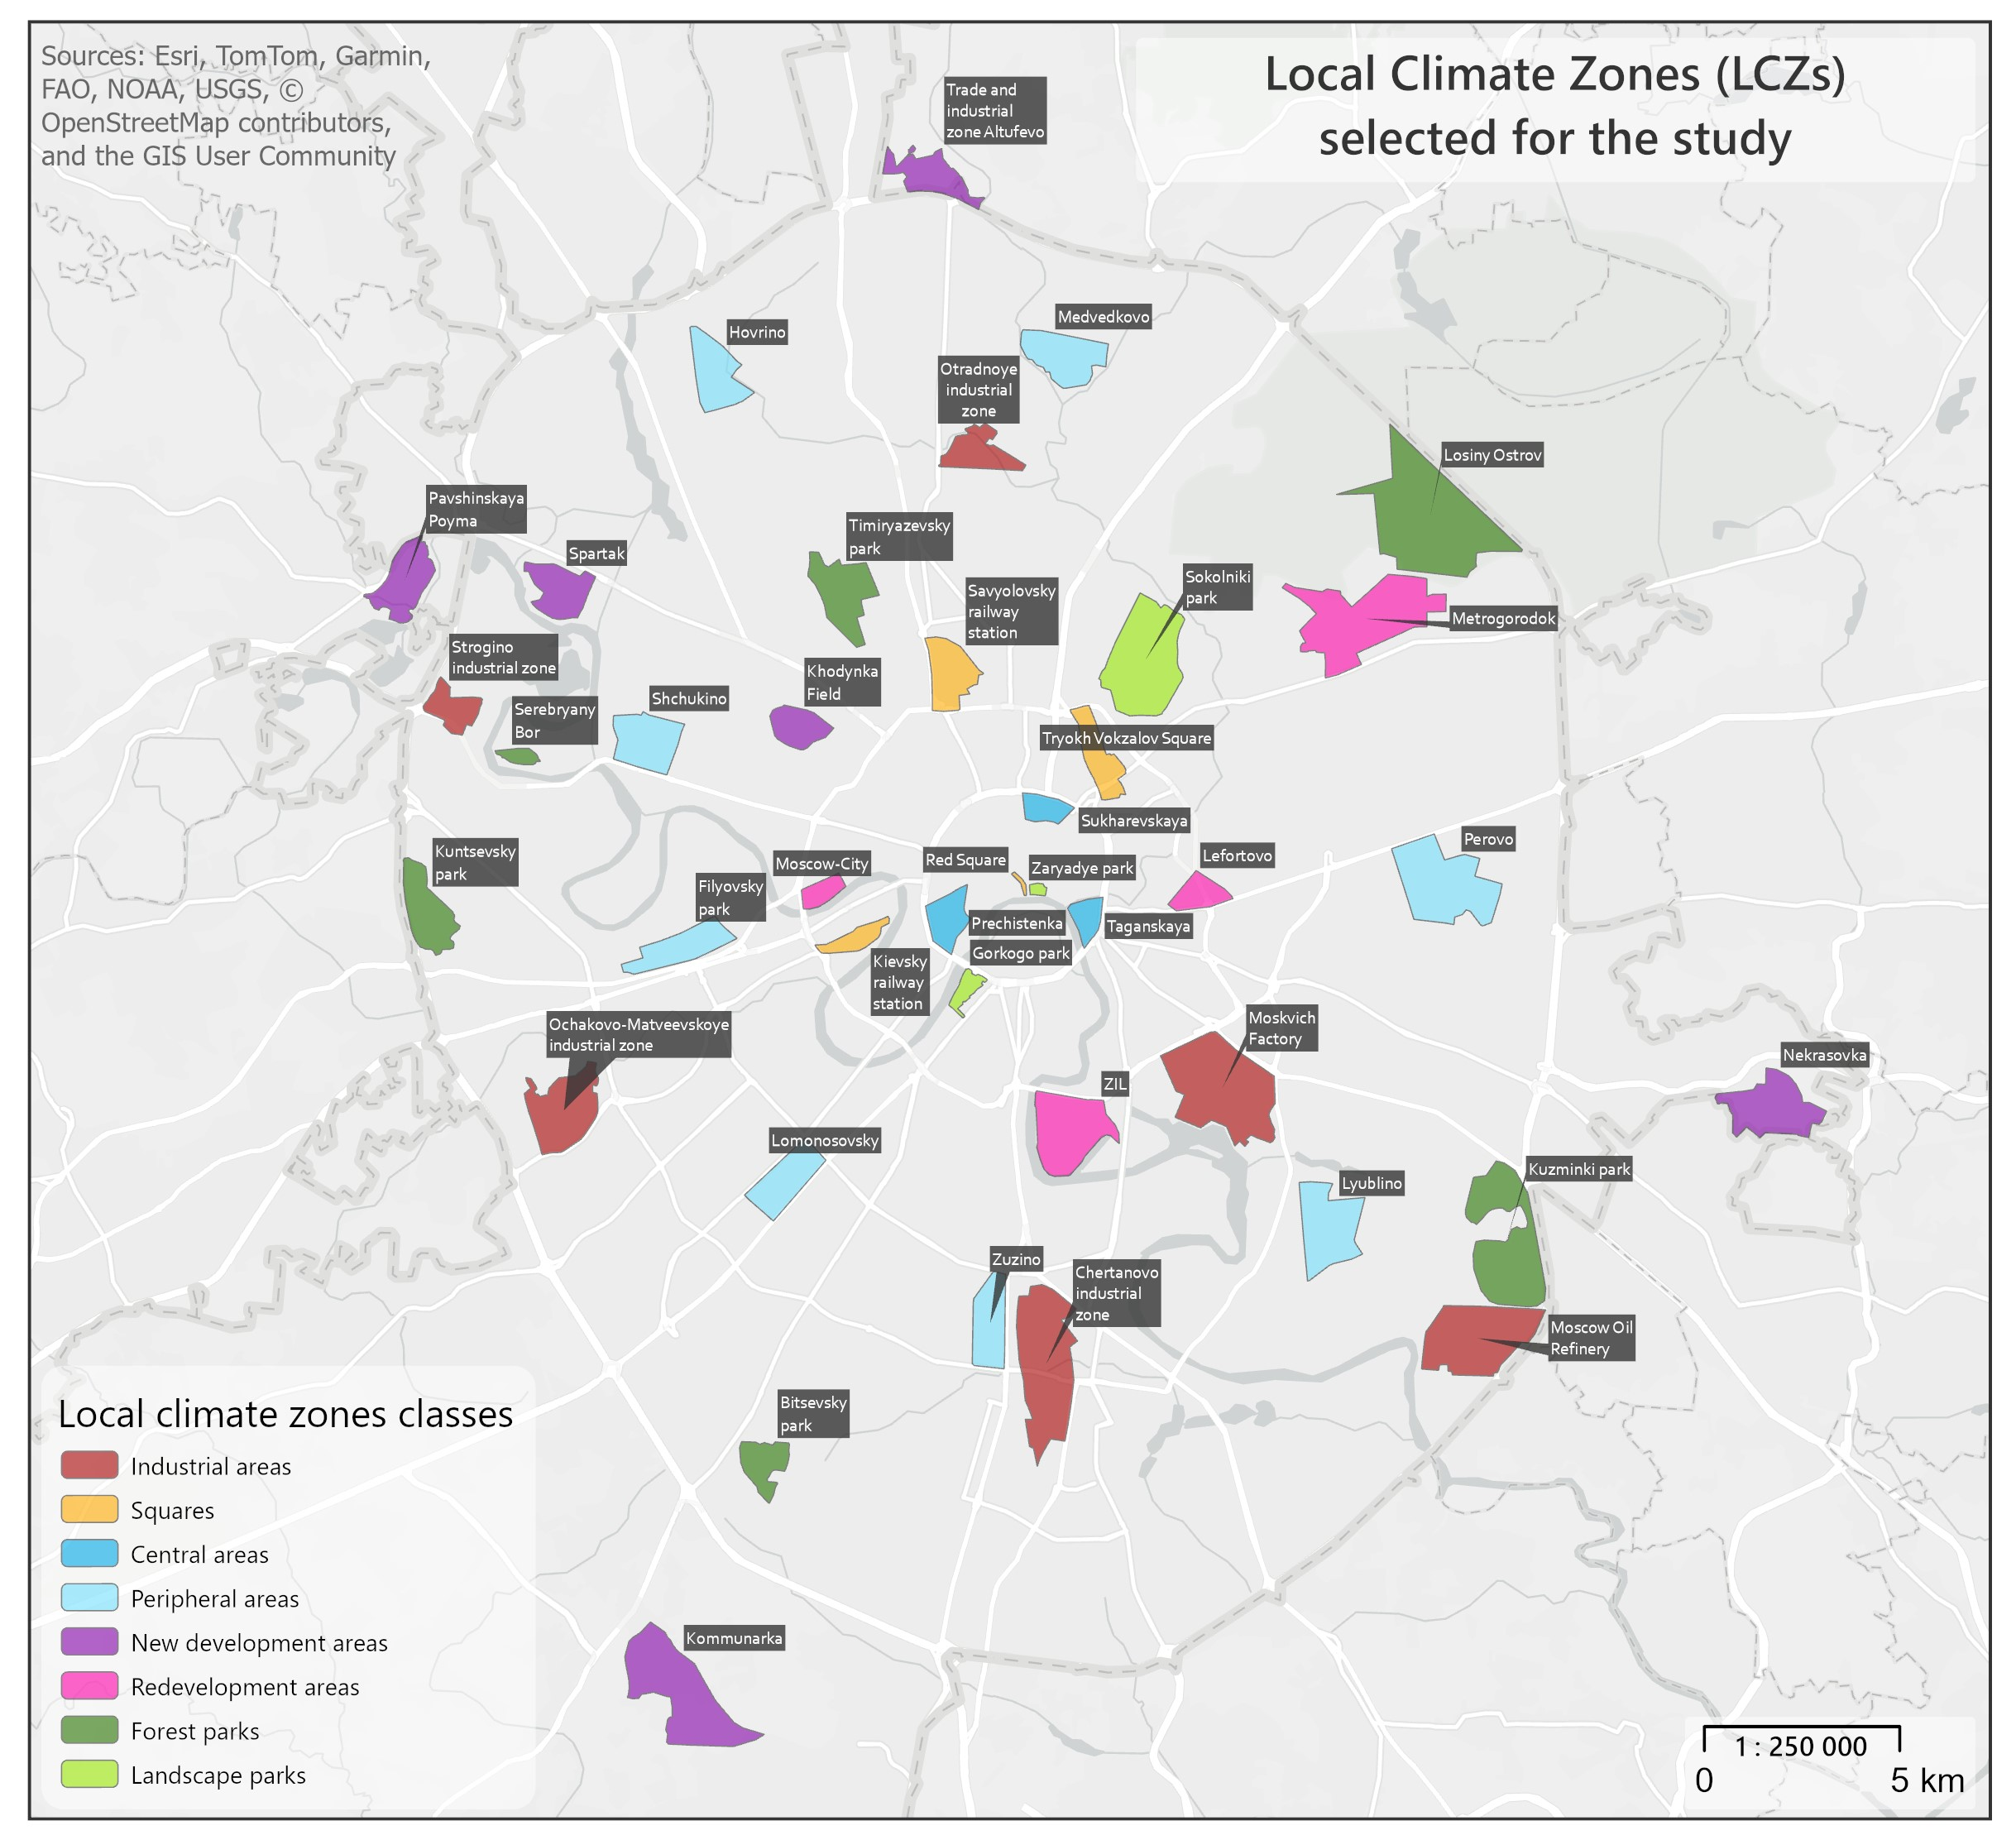

In [ ]:
df_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   system:index  1520 non-null   object 
 1   lcz           1520 non-null   int64  
 2   lcz_id        1520 non-null   int64  
 3   lcz_name      1520 non-null   object 
 4   mean_BU       1489 non-null   float64
 5   mean_LST      1489 non-null   float64
 6   mean_NDBI     1489 non-null   float64
 7   en_name       1520 non-null   object 
 8   rus_name      1520 non-null   object 
 9   year          1520 non-null   float64
 10  .geo          1520 non-null   object 
dtypes: float64(4), int64(2), object(5)
memory usage: 130.8+ KB


In [ ]:
df = df_orig.drop(['system:index',  '.geo', 'rus_name'], axis=1)

# Drop useless columns

In [ ]:
df['mean_LST'] = df['mean_LST']-273.15

# Kelvin to Celsius

In [ ]:
classes = {1:'Industrial areas', 2:'Squares', 3:'Forest parks', 4:'Central areas', 5:'Peripheral areas',
           6:'Landscape parks', 7:'Redevelopment areas', 8:'New development areas'}

# Classes names according to unique LCZ classes

In [ ]:
df['classname'] = df['lcz'].apply(lambda classid: classes[classid])

# Assigning class names to each polygon

In [ ]:
df.sample(5)

,lcz,lcz_id,lcz_name,mean_BU,mean_LST,mean_NDBI,en_name,year,classname
596,3,36,timiryazevka,-1.067551,20.492552,-0.381057,Timiryazevsky park,2013.0,Forest parks
1072,6,62,gorkogo,-0.591192,26.845725,-0.234114,Gorkogo park,1992.0,Landscape parks
1314,8,81,hodynka,-0.135928,22.142981,-0.029563,Khodynka Field,2008.0,New development areas
439,3,32,bitza,-1.027438,23.508719,-0.360541,Bitsevsky park,2007.0,Forest parks
827,5,53,lublino,-0.647250,28.479531,-0.234293,Lyublino,2016.0,Peripheral areas


In [ ]:
df['year'] = df['year'].astype(int)

# Years to integer

In [ ]:
polygons_id = df['lcz_id'].unique()
polygons_id

# Unique numbers of LCZ polygons

array([11, 12, 13, 14, 15, 16, 21, 22, 23, 24, 31, 32, 33, 34, 35, 36, 41,
       42, 43, 51, 52, 53, 54, 55, 56, 57, 58, 61, 62, 63, 71, 72, 73, 74,
       81, 82, 83, 84, 85, 86], dtype=int64)

In [ ]:
classes = df['lcz'].unique()
classes

# Unique classes numbers

array([1, 2, 3, 4, 5, 6, 7, 8], dtype=int64)

In [ ]:
df['mean_LST'].isna().sum()/len(df)*100

# NaN percent

2.0394736842105265

In [ ]:
df.corr(numeric_only=True)[['mean_LST', 'mean_BU']].loc['mean_LST']

# Pearson corr between LST and и BU-index = 0.68

mean_LST    1.000000
mean_BU     0.682457
Name: mean_LST, dtype: float64

## Linear trend check based on the raw data

Calculate and plot linear trend

In [ ]:
df_clean = df.dropna(subset=['mean_LST'])

# Drop empty data

In [ ]:
df_clean = df_clean.reset_index()
df_clean = df_clean.set_index('lcz_id')

# Look through polygons

In [ ]:
df_clean

,index,lcz,lcz_name,mean_BU,mean_LST,mean_NDBI,en_name,year,classname
lcz_id,,,,,,,,,
11,0,1,moscvich,-0.273184,28.987634,-0.094475,Moskvich Factory,1984,Industrial areas
11,1,1,moscvich,-0.272194,31.026099,-0.092253,Moskvich Factory,1985,Industrial areas
11,2,1,moscvich,-0.256523,30.137335,-0.092258,Moskvich Factory,1986,Industrial areas
11,3,1,moscvich,-0.235384,27.762883,-0.077059,Moskvich Factory,1987,Industrial areas
11,4,1,moscvich,-0.254030,40.644346,-0.077408,Moskvich Factory,1988,Industrial areas
...,...,...,...,...,...,...,...,...,...
86,1515,8,severny,-0.387575,33.617366,-0.147997,Trade and industrial zone Altufevo,2020,New development areas
86,1516,8,severny,-0.327059,37.982157,-0.079645,Trade and industrial zone Altufevo,2021,New development areas
86,1517,8,severny,-0.315141,36.272083,-0.076855,Trade and industrial zone Altufevo,2022,New development areas


Graph example

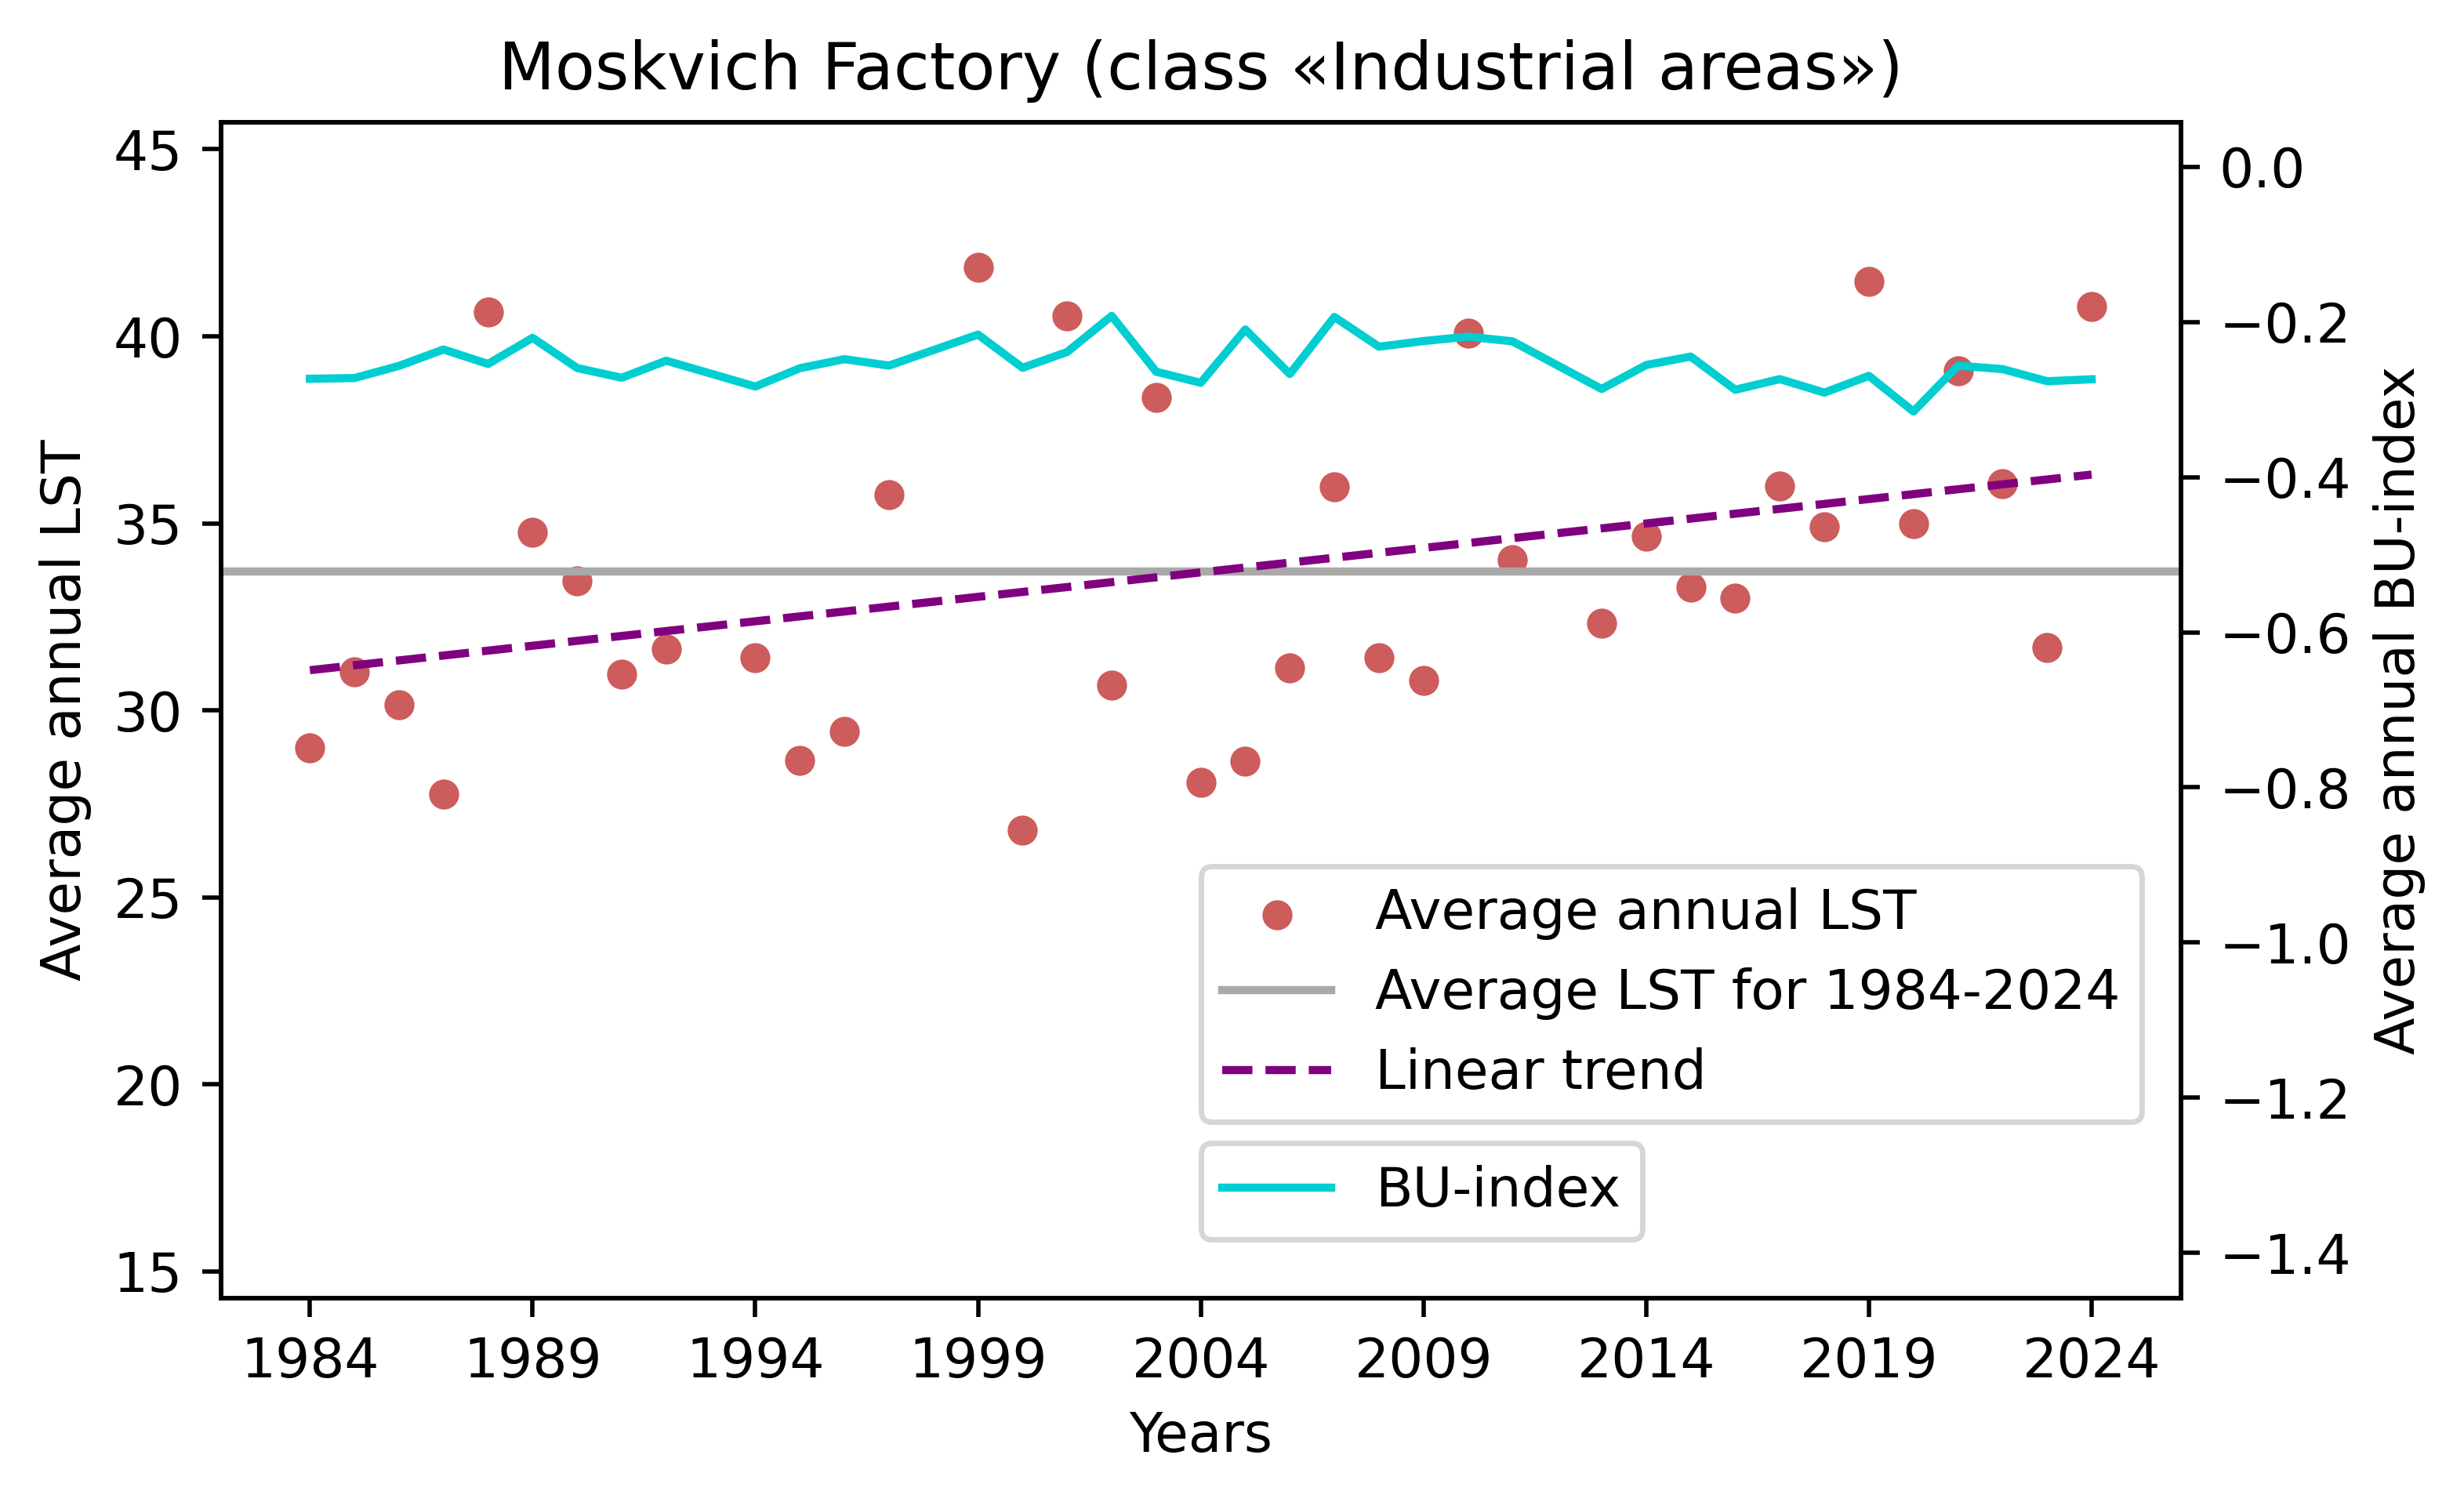

In [ ]:
# Example visualization

ts_poly_df_clean = df_clean.loc[11]

x = ts_poly_df_clean['year']
years_ticks = np.arange(x.min(), x.max()+1, 5)

y = ts_poly_df_clean['mean_LST']
ymin = df_clean['mean_LST'].min() - 1
ymax = df_clean['mean_LST'].max() + 2

y2 = ts_poly_df_clean['mean_BU']
y2min = df_clean['mean_BU'].min() - 0.2
y2max = df_clean['mean_BU'].max() + 0.1

fig = plt.figure(figsize=(5,3), dpi=500)
ax1 = fig.add_axes([0,0,1,1])
ax1.set_ylim(ymin, ymax)

sns.scatterplot(x=x, y=y, ax=ax1, color='indianred')
ax1.axhline(y.mean(), color='darkgrey')

coeffs = np.polyfit(x, y, 1)
polynomial = np.poly1d(coeffs)
ax1.plot(x, polynomial(x), color='purple', ls='--')
ax1.set_xlabel('Years')
ax1.set_xticks(years_ticks)
ax1.set_ylabel('Average annual LST')
plt.legend(['Average annual LST','Average LST for 1984-2024','Linear trend'], loc=[0.5,0.15])

ax2 = ax1.twinx()
ax2.set_ylim(y2min,y2max)
ax2.set_ylabel('Average annual BU-index')
sns.lineplot(x=x, y=y2, ax=ax2, color='darkturquoise')
plt.legend(['BU-index'], loc=[0.5,0.05])

title = plt.title(f'{ts_poly_df_clean["en_name"].iloc[0]} (class «{ts_poly_df_clean["classname"].iloc[0]}»)')
# plt.tight_layout()
# plt.savefig(f'D:\Kursach_2\comps\plots\{title}.png', bbox_inches='tight')
plt.show()

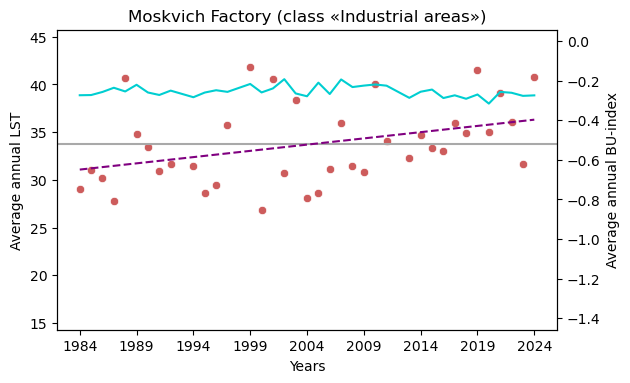

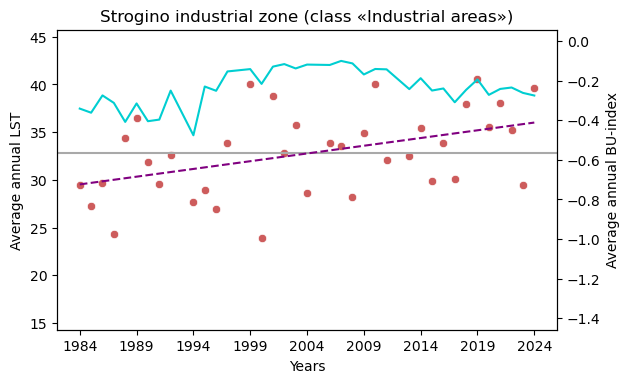

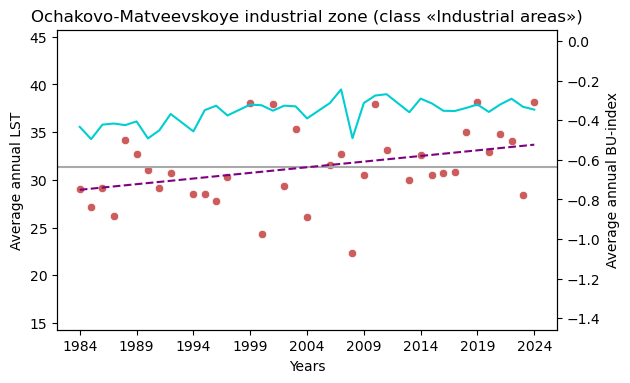

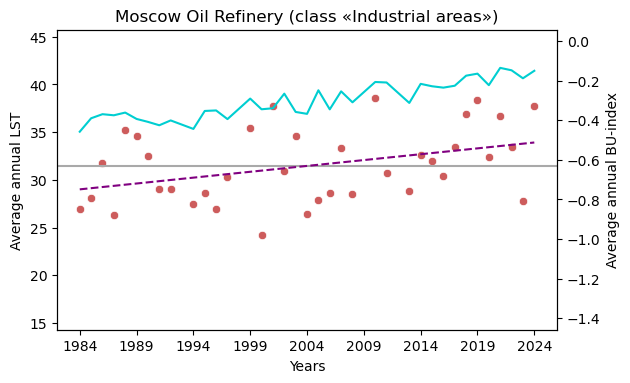

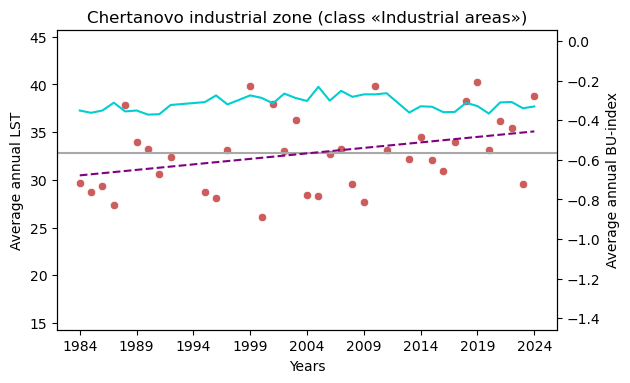

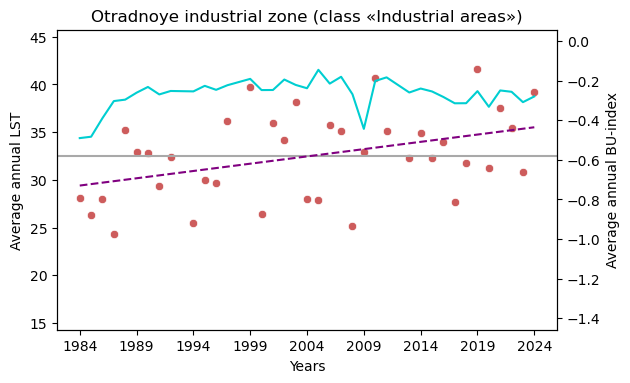

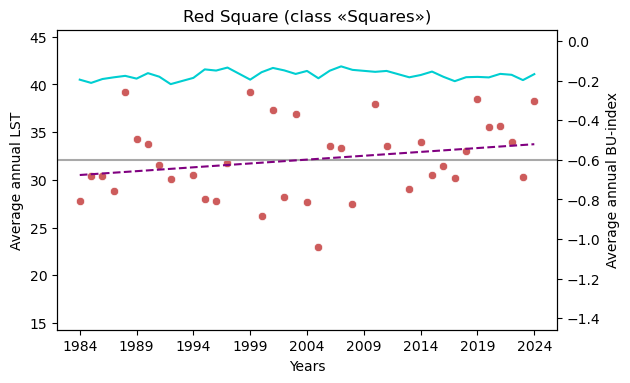

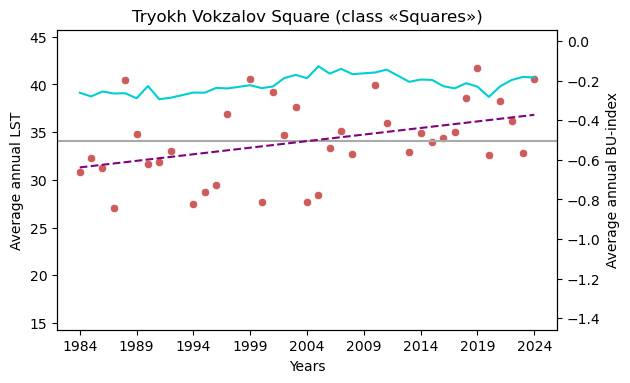

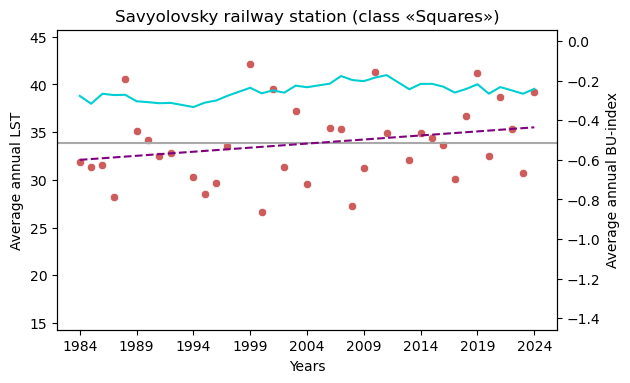

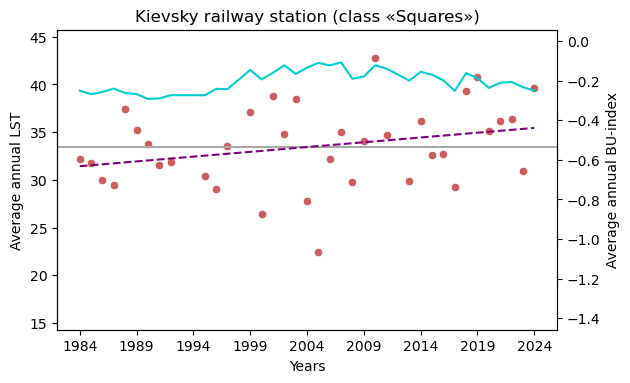

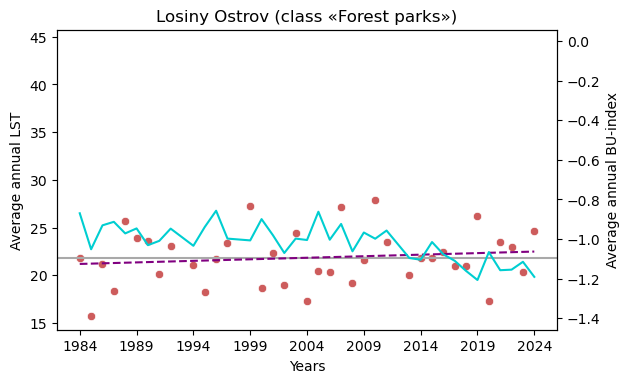

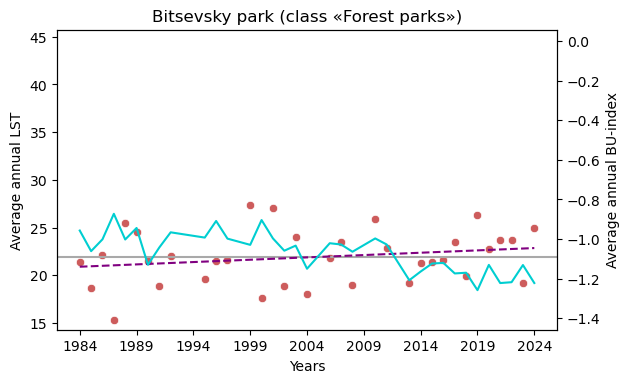

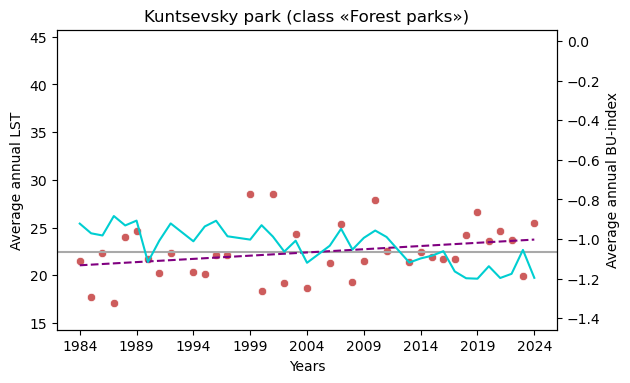

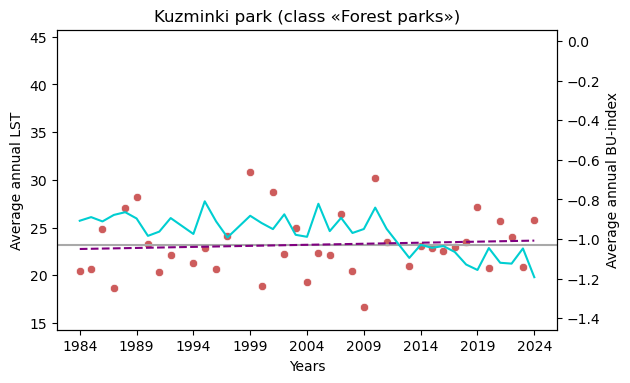

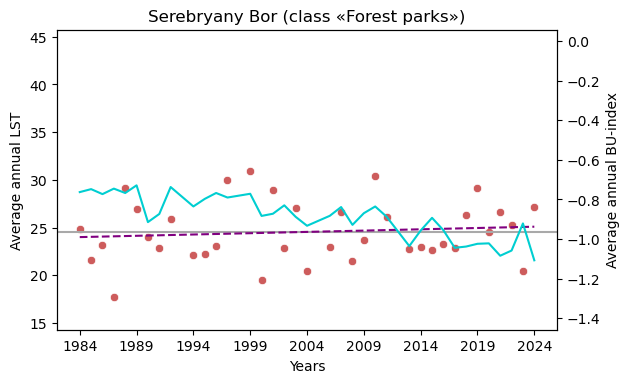

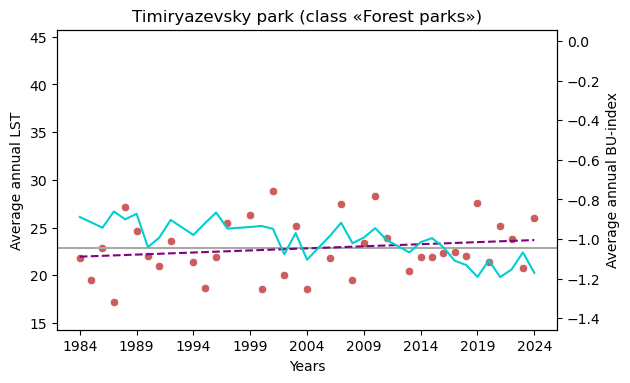

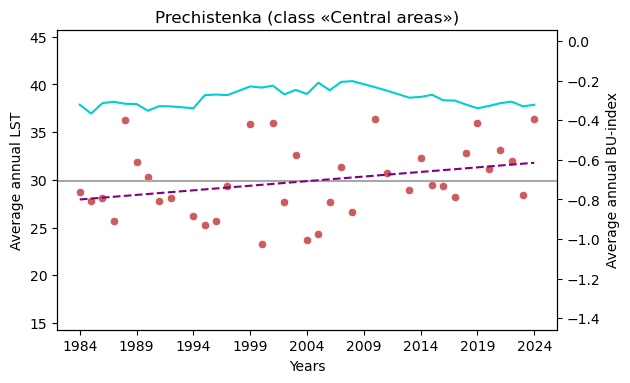

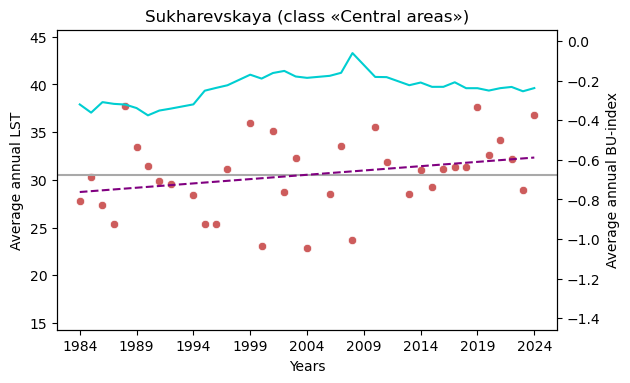

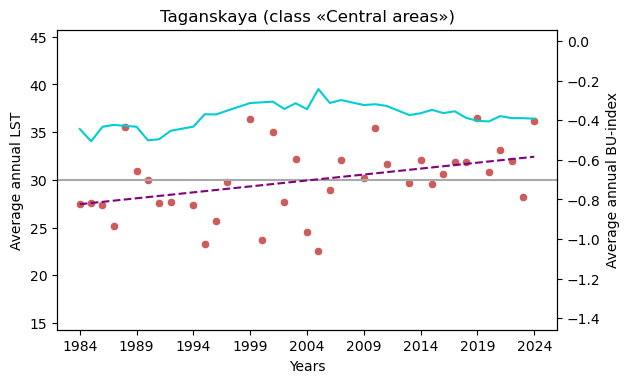

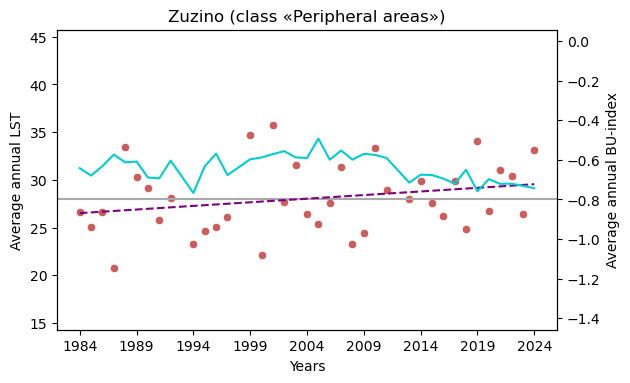

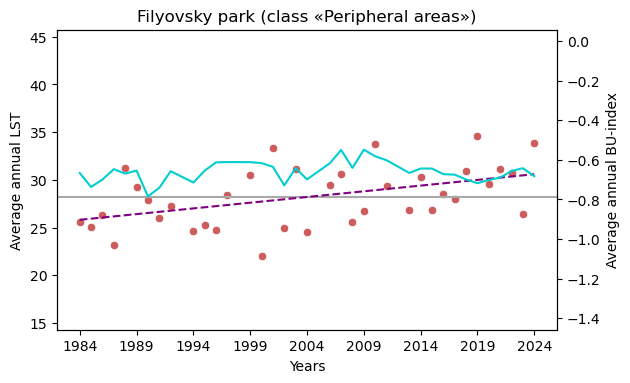

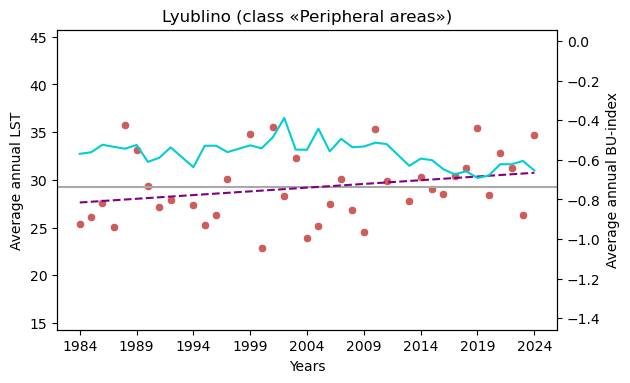

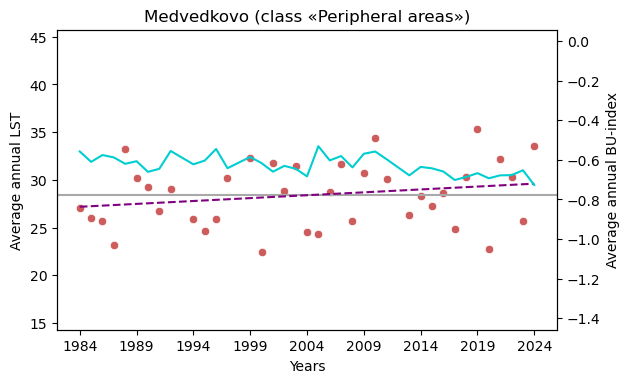

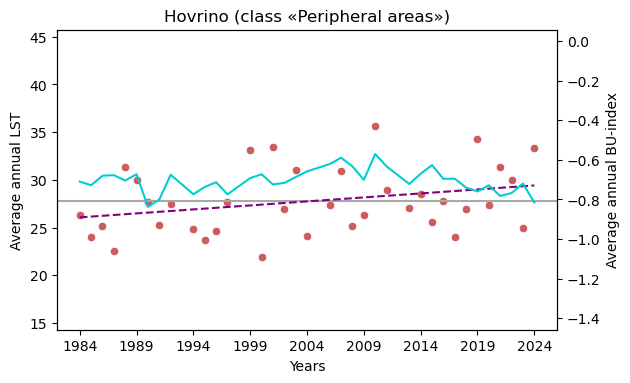

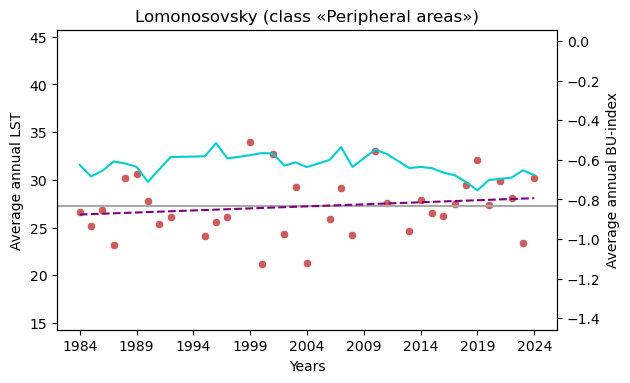

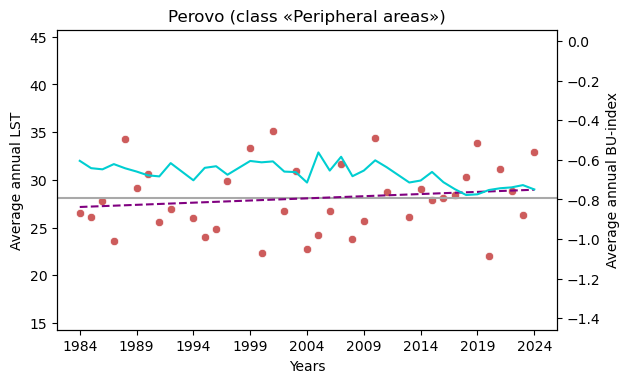

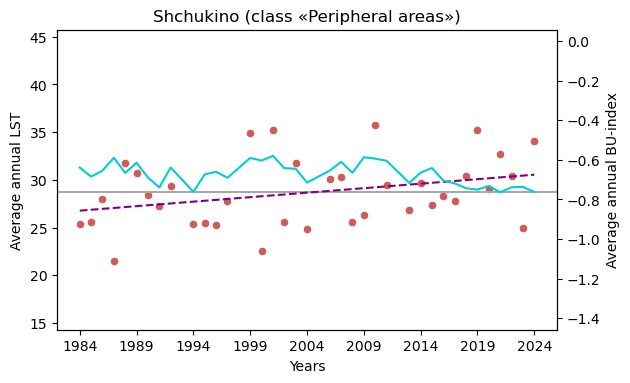

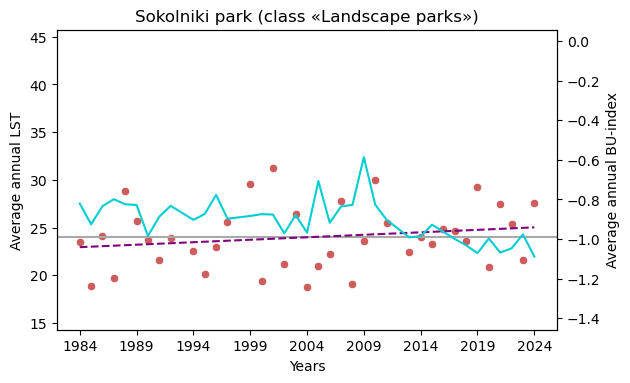

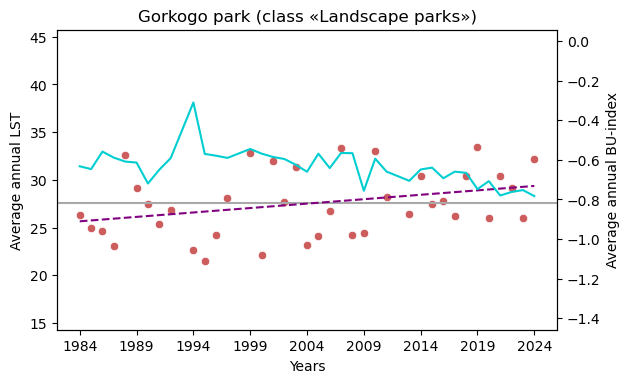

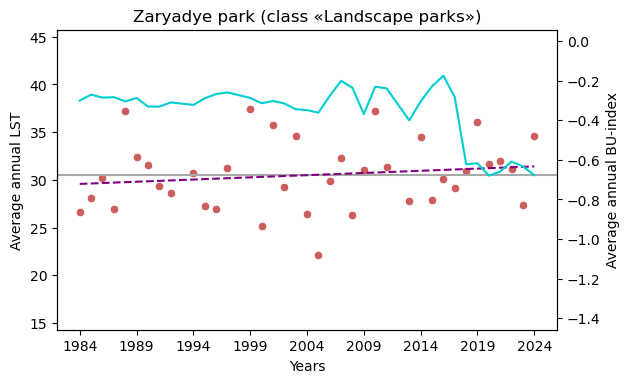

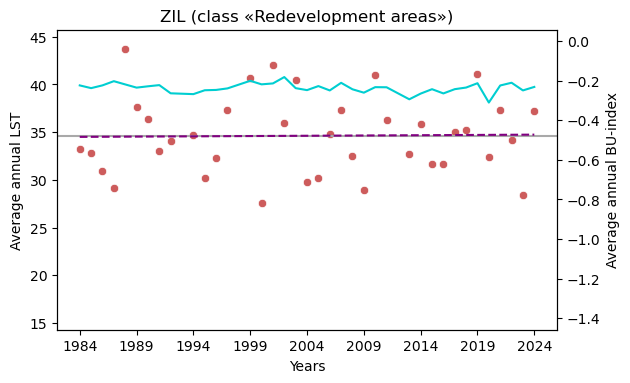

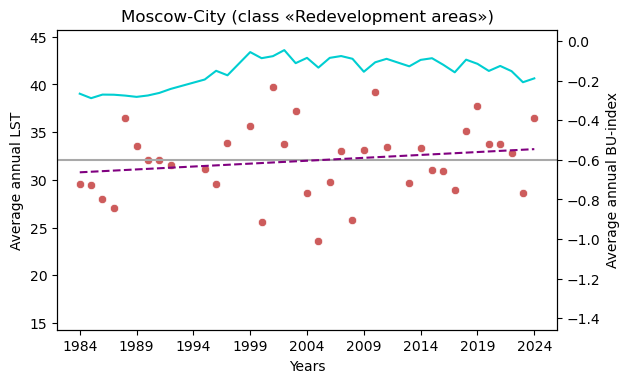

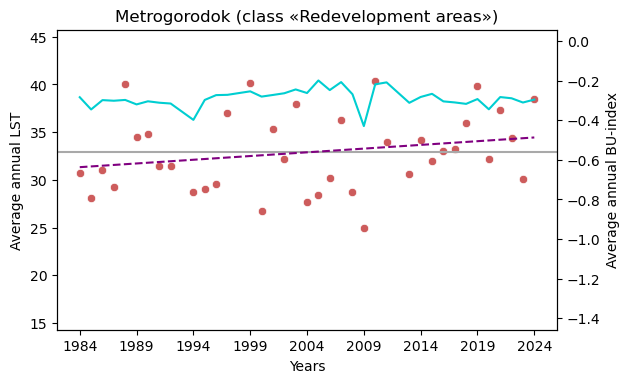

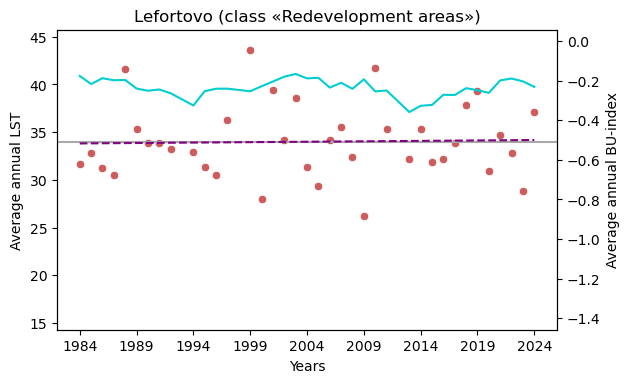

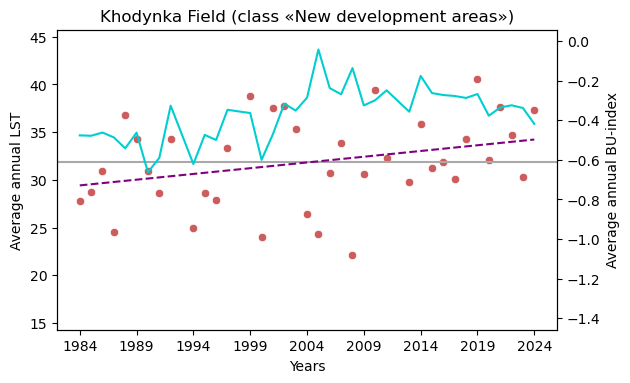

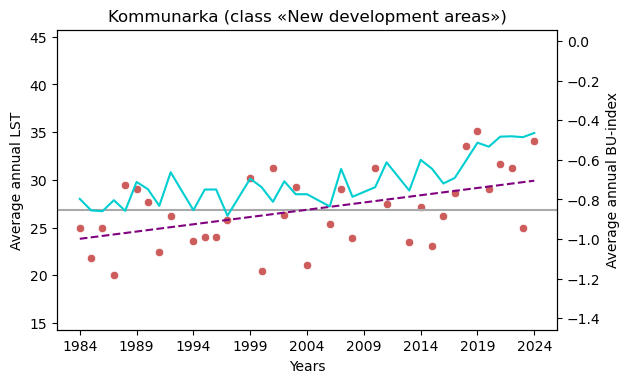

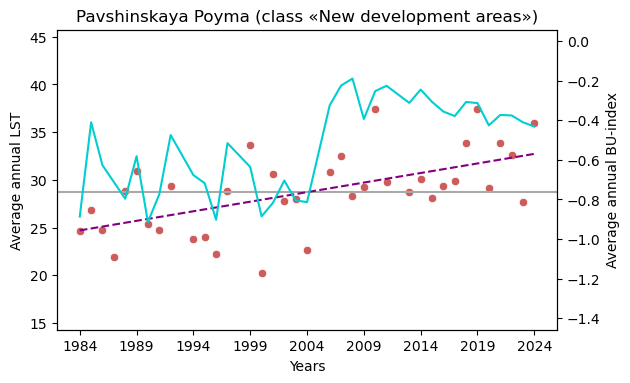

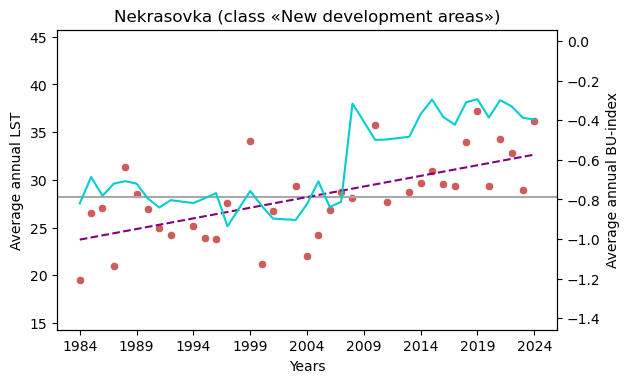

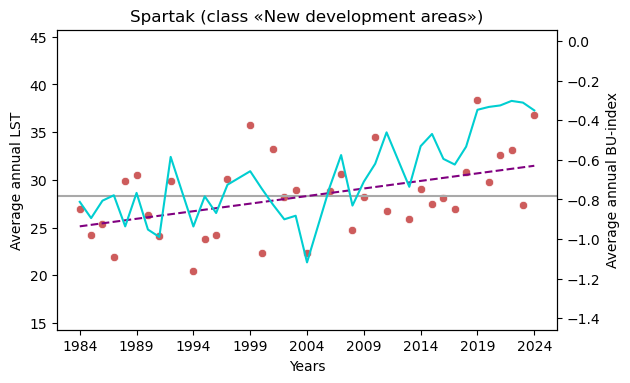

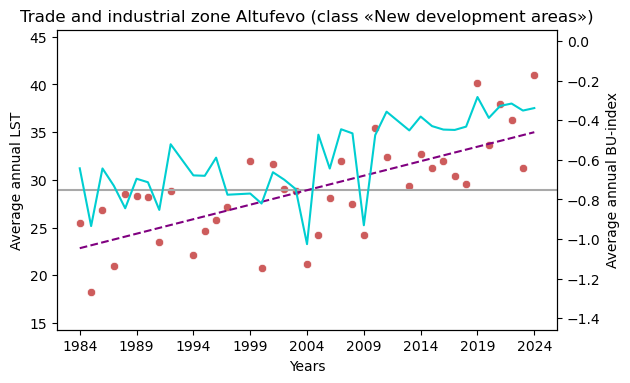

In [ ]:
for ID in polygons_id:

    ts_poly_df_clean = df_clean.loc[ID]

    x = ts_poly_df_clean['year']
    years_ticks = np.arange(x.min(), x.max()+1, 5)

    y = ts_poly_df_clean['mean_LST']
    ymin = df_clean['mean_LST'].min() - 1
    ymax = df_clean['mean_LST'].max() + 2

    y2 = ts_poly_df_clean['mean_BU']
    y2min = df_clean['mean_BU'].min() - 0.2
    y2max = df_clean['mean_BU'].max() + 0.1

    fig = plt.figure(figsize=(5,3))
    ax1 = fig.add_axes([0,0,1,1])
    ax1.set_ylim(ymin, ymax)

    sns.scatterplot(x=x, y=y, ax=ax1, color='indianred')
    ax1.axhline(y.mean(), color='darkgrey')

    coeffs = np.polyfit(x, y, 1)
    polynomial = np.poly1d(coeffs)
    ax1.plot(x, polynomial(x), color='purple', ls='--')
    ax1.set_xlabel('Years')
    ax1.set_xticks(years_ticks)
    ax1.set_ylabel('Average annual LST')

    ax2 = ax1.twinx()
    ax2.set_ylim(y2min,y2max)
    ax2.set_ylabel('Average annual BU-index')
    sns.lineplot(x=x, y=y2, ax=ax2, color='darkturquoise')

    title = plt.title(f'{ts_poly_df_clean["en_name"].iloc[0]} (class «{ts_poly_df_clean["classname"].iloc[0]}»)')
   # plt.tight_layout()
   # plt.savefig(f'D:\Kursach_2\comps\plots\{title}.png', bbox_inches='tight')
    plt.show()

Statistical test of trend significance

In [ ]:
df_clean

,index,lcz,lcz_name,mean_BU,mean_LST,mean_NDBI,en_name,year,classname
lcz_id,,,,,,,,,
11,0,1,moscvich,-0.273184,28.987634,-0.094475,Moskvich Factory,1984,Industrial areas
11,1,1,moscvich,-0.272194,31.026099,-0.092253,Moskvich Factory,1985,Industrial areas
11,2,1,moscvich,-0.256523,30.137335,-0.092258,Moskvich Factory,1986,Industrial areas
11,3,1,moscvich,-0.235384,27.762883,-0.077059,Moskvich Factory,1987,Industrial areas
11,4,1,moscvich,-0.254030,40.644346,-0.077408,Moskvich Factory,1988,Industrial areas
...,...,...,...,...,...,...,...,...,...
86,1515,8,severny,-0.387575,33.617366,-0.147997,Trade and industrial zone Altufevo,2020,New development areas
86,1516,8,severny,-0.327059,37.982157,-0.079645,Trade and industrial zone Altufevo,2021,New development areas
86,1517,8,severny,-0.315141,36.272083,-0.076855,Trade and industrial zone Altufevo,2022,New development areas


In [ ]:
results = []

for poly_id in polygons_id:

    # Filter by polygon
    ts_poly = df_clean.loc[poly_id]

    x = ts_poly['year'].values
    y = ts_poly['mean_LST'].values

    # Linear regression
    slope, intercept, r_value, p_value, std_err = st.linregress(x, y)

    # Save a result
    results.append({
        'class': ts_poly['lcz'].iloc[0],
        'lcz_id': poly_id,
        'lcz_name': ts_poly['en_name'].iloc[0],  # Get the first row as name
        'n_points': len(ts_poly),
        'slope': slope,
        'intercept': intercept,
        'r_value': r_value,
        'p_value': p_value,
        'std_err': std_err
    })

# To DataFrame
results_df = pd.DataFrame(results)

In [ ]:
results_df

,class,lcz_id,lcz_name,n_points,slope,intercept,r_value,p_value,std_err
0,1,11,Moskvich Factory,38,0.130765,-228.365502,0.375792,2.006672e-02,0.053744
1,1,12,Strogino industrial zone,37,0.162024,-291.936446,0.451539,5.027605e-03,0.054117
2,1,13,Ochakovo-Matveevskoye industrial zone,37,0.118237,-205.631368,0.370808,2.386184e-02,0.050055
3,1,14,Moscow Oil Refinery,37,0.122761,-214.558833,0.390669,1.681825e-02,0.048894
4,1,15,Chertanovo industrial zone,37,0.115194,-198.080149,0.358904,2.914978e-02,0.050638
5,1,16,Otradnoye industrial zone,38,0.152717,-273.592570,0.411191,1.032830e-02,0.056425
6,2,21,Red Square,37,0.080689,-129.584444,0.247991,1.388938e-01,0.053280
7,2,22,Tryokh Vokzalov Square,37,0.137777,-242.051247,0.413057,1.105716e-02,0.051347
8,2,23,Savyolovsky railway station,37,0.085237,-137.018483,0.257951,1.232152e-01,0.053964
9,2,24,Kievsky railway station,37,0.100271,-167.510994,0.288416,8.342397e-02,0.056268


In [ ]:
nonvalid_poly = results_df[results_df['p_value']>0.05]

In [ ]:
nonvalid_poly.groupby('class').count()['p_value']

# Number of polygons with insignificant trend at significance level 0.05

class
2    3
3    6
4    2
5    6
6    2
7    4
8    1
Name: p_value, dtype: int64

In [ ]:
valid_poly = results_df[results_df['p_value']<0.05].sort_values('slope', ascending=False)

In [ ]:
valid_poly.groupby('class').count()['p_value']

# Number of polygons with significant trend at significance level 0.05

class
1    6
2    1
4    1
5    2
6    1
8    5
Name: p_value, dtype: int64

In [ ]:
print('Percentage of polygons with insignificant trend:', len(results_df[results_df['p_value']>0.05])/len(results_df)*100)

Percentage of polygons with insignificant trend: 60.0


In [ ]:
results_df[results_df['p_value']<0.05].sort_values('slope',ascending=False)

# Polygons with significant trend

,class,lcz_id,lcz_name,n_points,slope,intercept,r_value,p_value,std_err
39,8,86,Trade and industrial zone Altufevo,38,0.303915,-580.134609,0.705110,7.709641e-07,0.050939
37,8,84,Nekrasovka,36,0.222683,-418.071050,0.637175,2.930977e-05,0.046194
36,8,83,Pavshinskaya Poyma,37,0.200457,-373.007838,0.588290,1.284860e-04,0.046575
1,1,12,Strogino industrial zone,37,0.162024,-291.936446,0.451539,5.027605e-03,0.054117
38,8,85,Spartak,37,0.158696,-289.729726,0.463757,3.840138e-03,0.051246
5,1,16,Otradnoye industrial zone,38,0.152717,-273.592570,0.411191,1.032830e-02,0.056425
35,8,82,Kommunarka,36,0.152229,-278.204923,0.489584,2.441112e-03,0.046497
7,2,22,Tryokh Vokzalov Square,37,0.137777,-242.051247,0.413057,1.105716e-02,0.051347
0,1,11,Moskvich Factory,38,0.130765,-228.365502,0.375792,2.006672e-02,0.053744
18,4,43,Taganskaya,37,0.124449,-219.465923,0.411370,1.142314e-02,0.046609


In [ ]:
results_df[results_df['p_value']>0.05].sort_values('slope',ascending=False)

,class,lcz_id,lcz_name,n_points,slope,intercept,r_value,p_value,std_err
34,8,81,Khodynka Field,38,0.120236,-209.134265,0.312526,0.056089,0.060908
9,2,24,Kievsky railway station,37,0.100271,-167.510994,0.288416,0.083424,0.056268
16,4,41,Prechistenka,37,0.096228,-162.979797,0.317494,0.055514,0.048580
17,4,42,Sukharevskaya,36,0.090310,-150.456509,0.287365,0.089245,0.051624
8,2,23,Savyolovsky railway station,37,0.085237,-137.018483,0.257951,0.123215,0.053964
23,5,55,Hovrino,37,0.083722,-140.043156,0.299292,0.071933,0.045116
6,2,21,Red Square,37,0.080689,-129.584444,0.247991,0.138894,0.053280
32,7,73,Metrogorodok,38,0.077804,-123.037941,0.232669,0.159803,0.054203
21,5,53,Lyublino,38,0.077787,-126.706461,0.264365,0.108737,0.047295
19,5,51,Zuzino,38,0.075756,-123.792897,0.253782,0.124183,0.048123


Polygons detrending using scipy.detrend

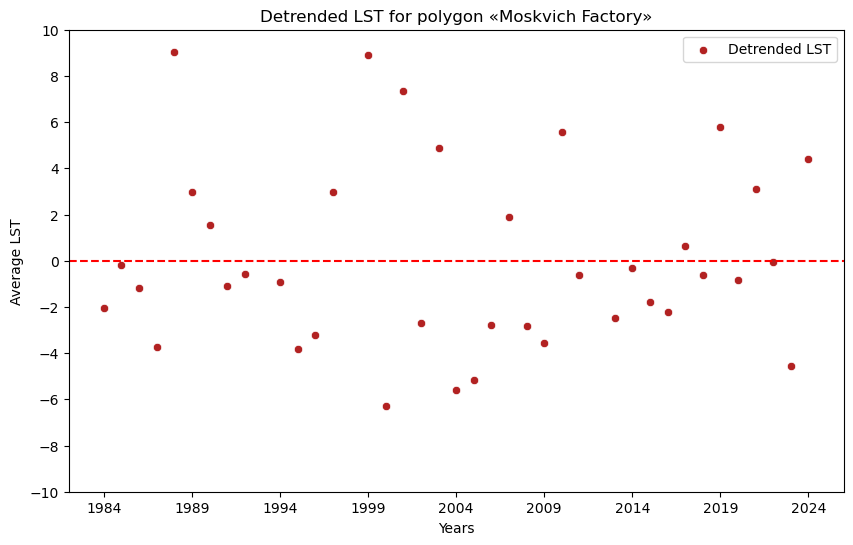

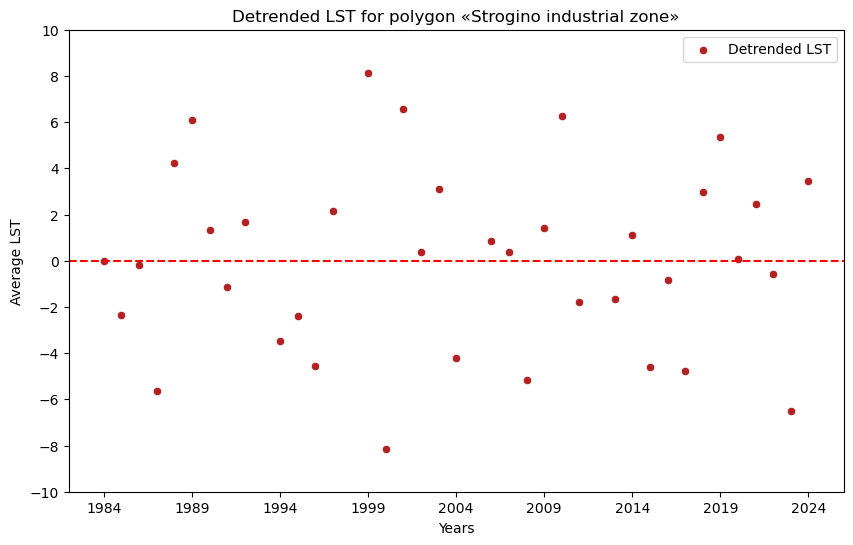

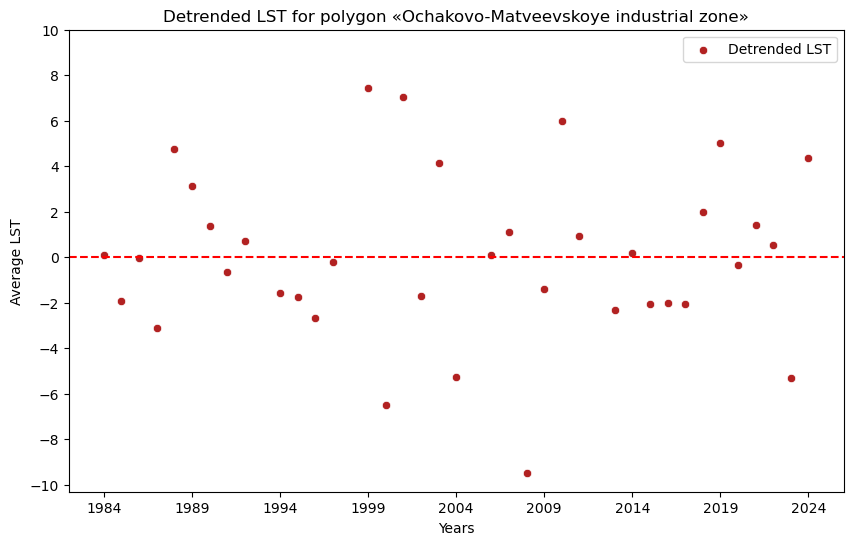

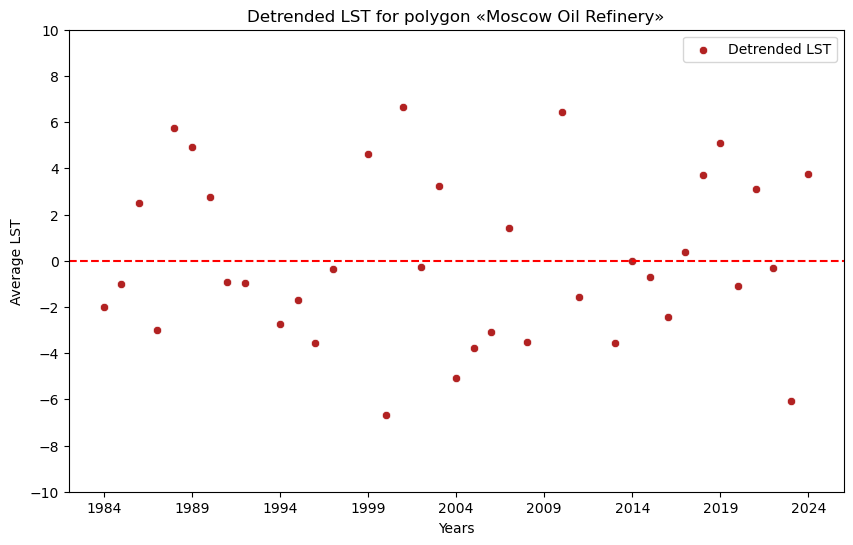

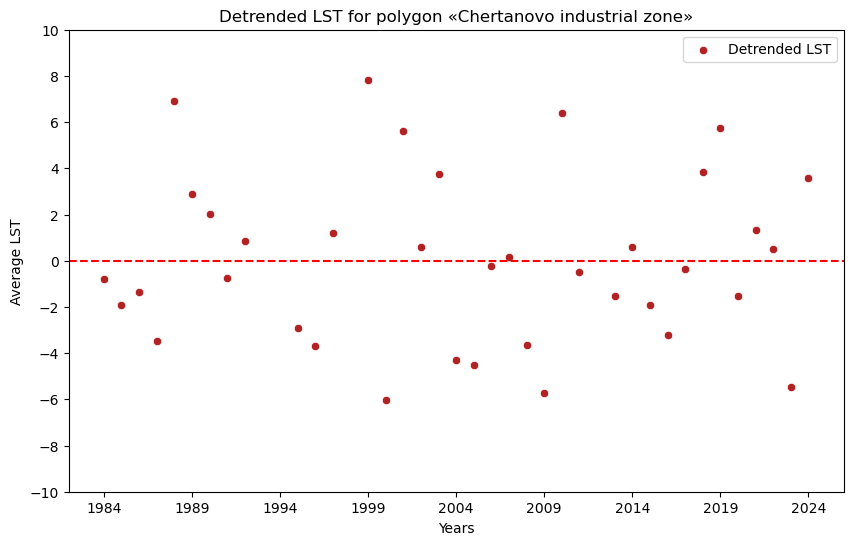

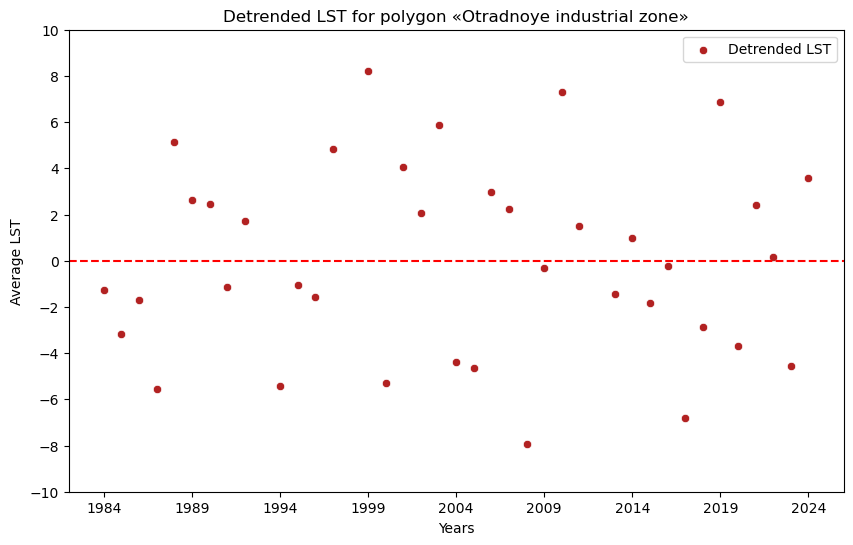

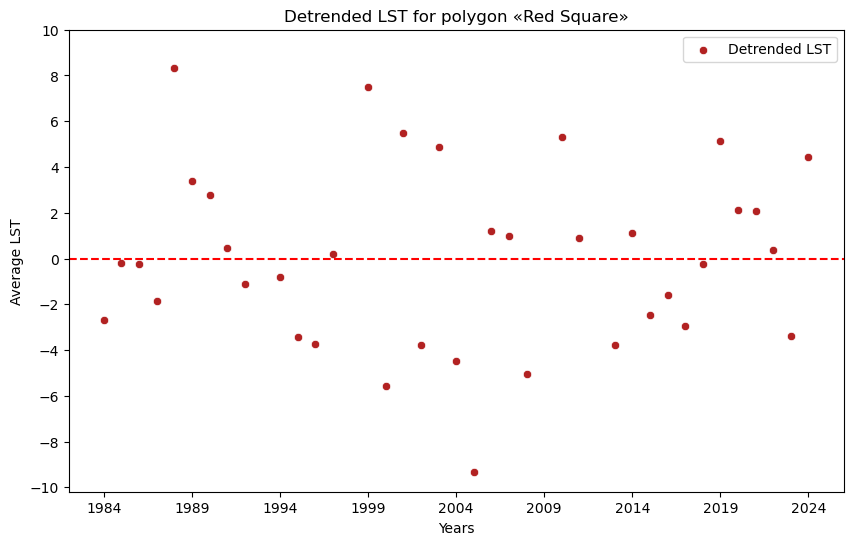

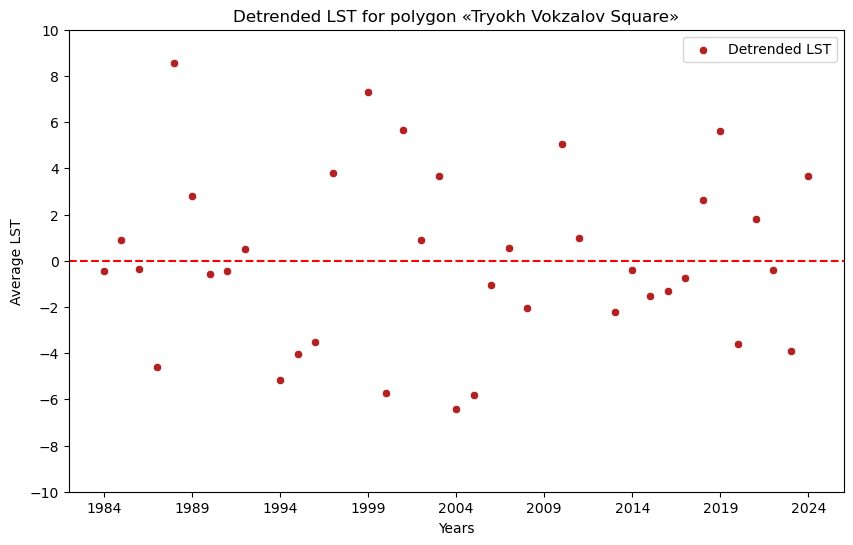

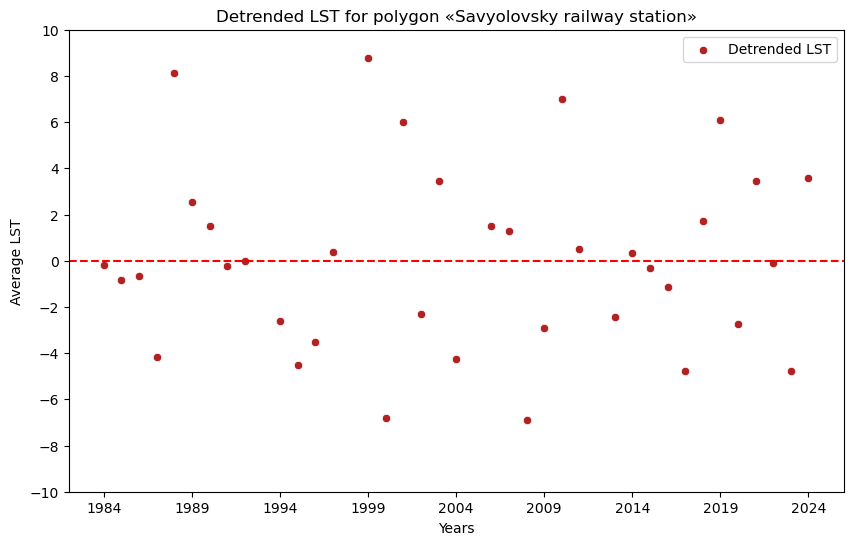

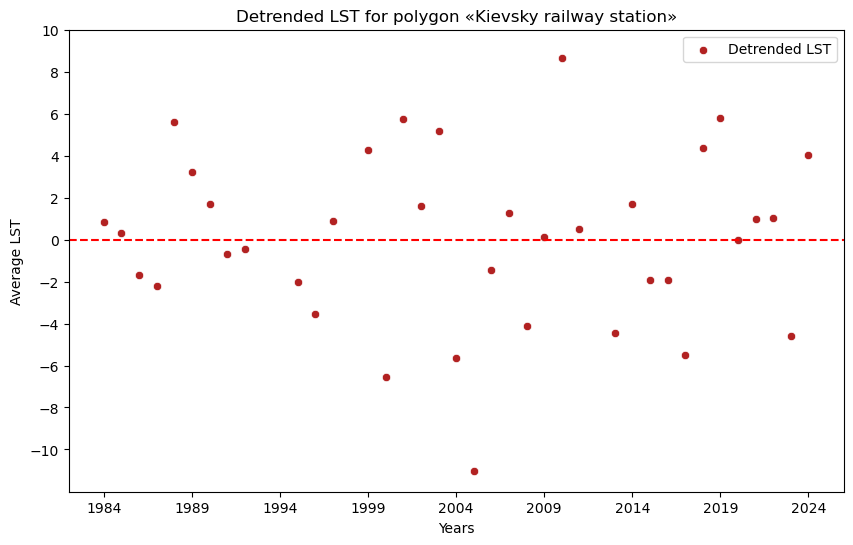

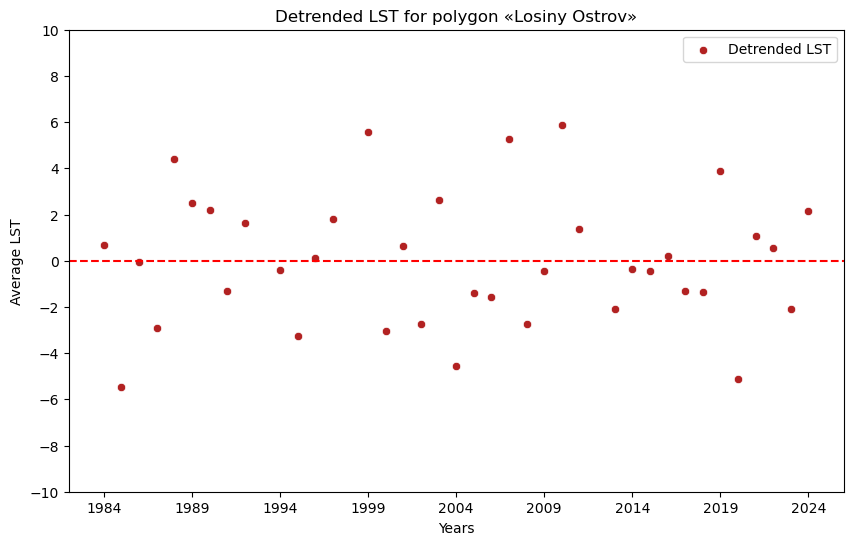

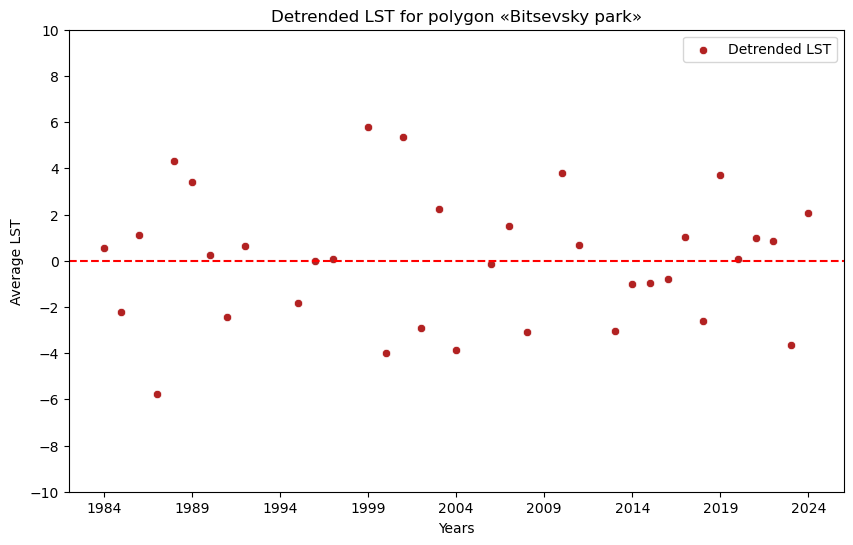

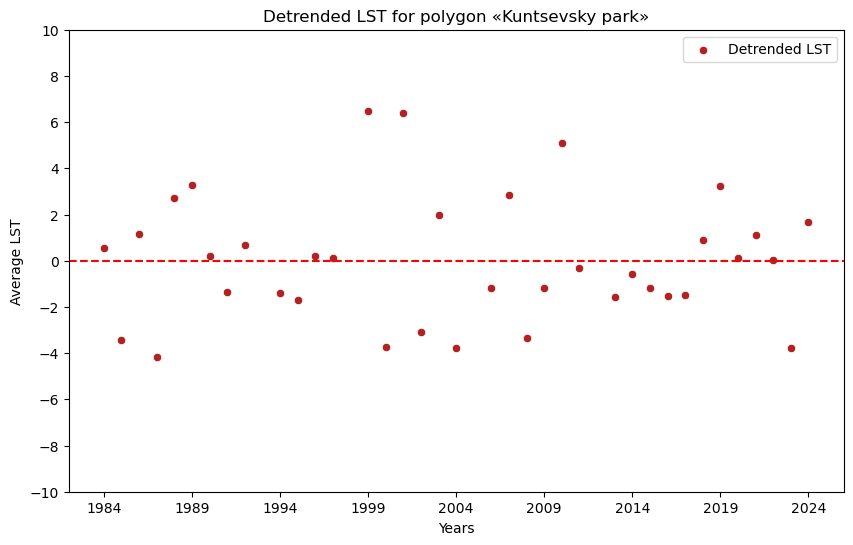

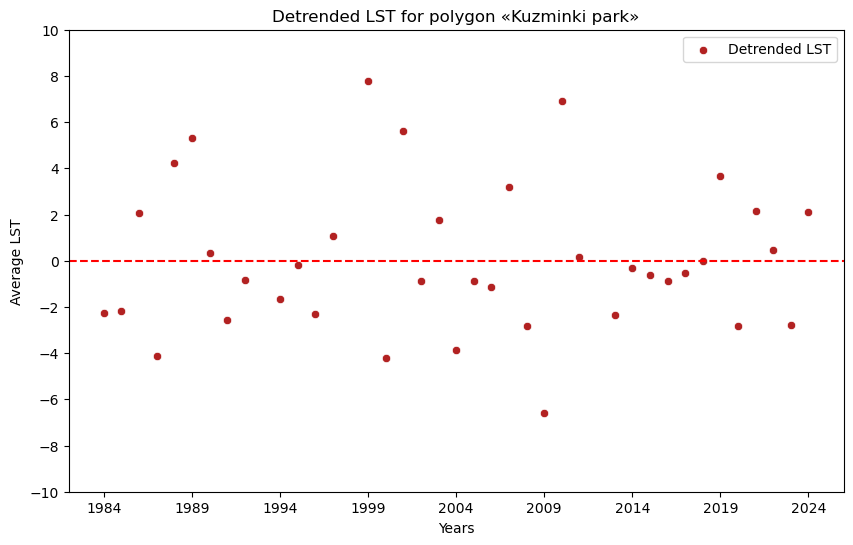

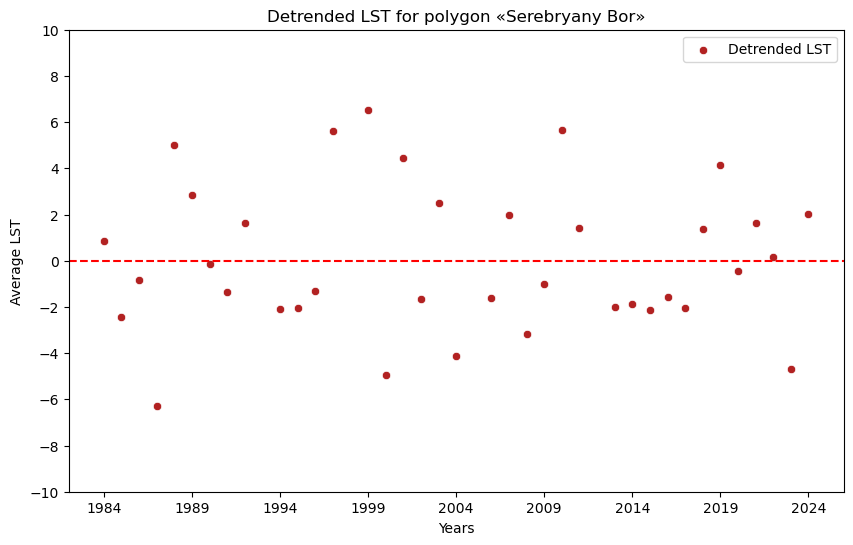

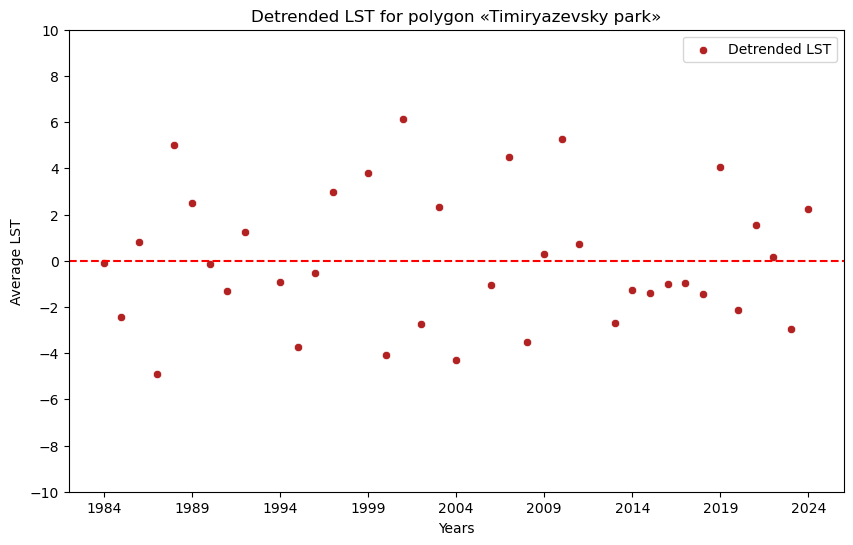

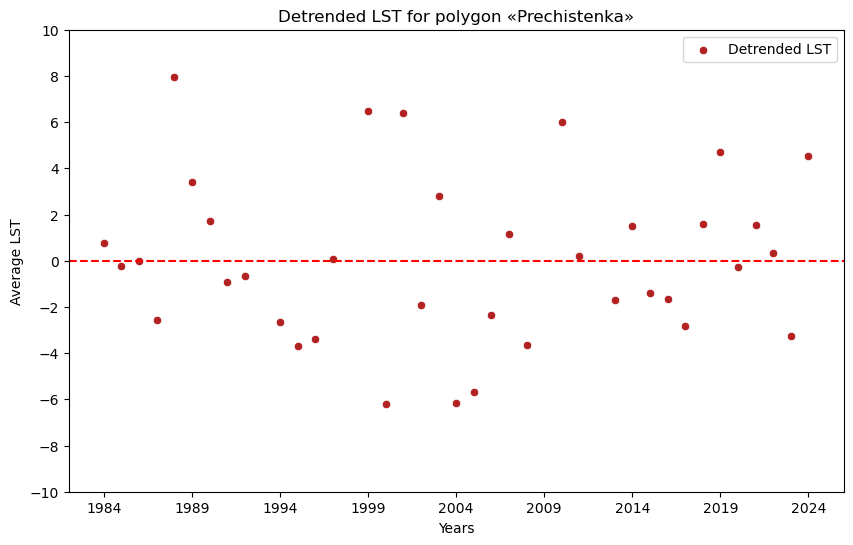

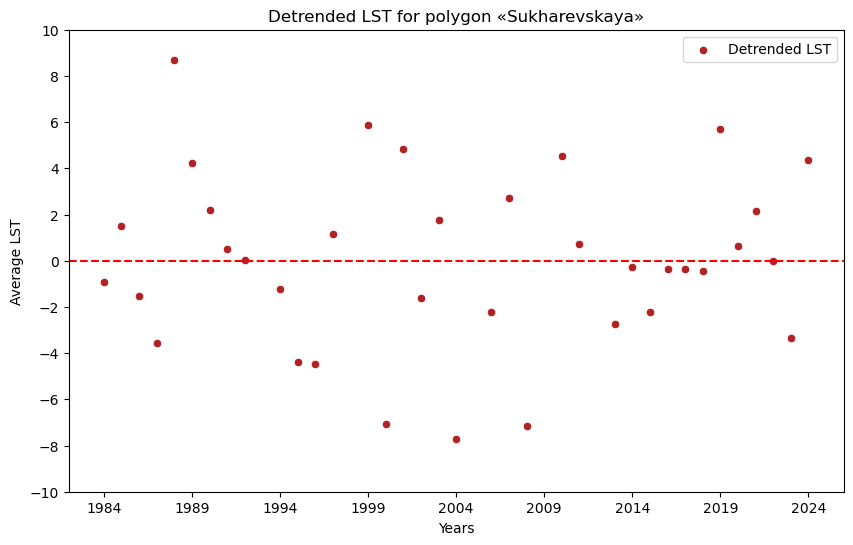

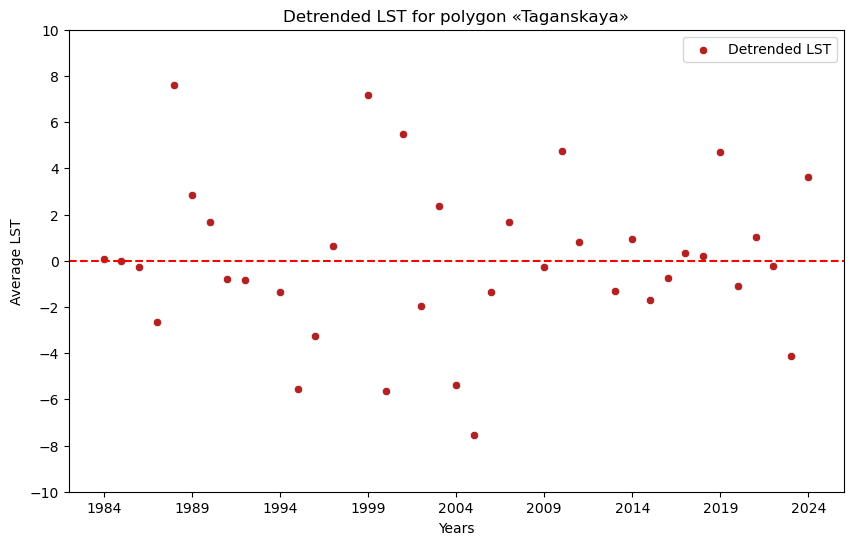

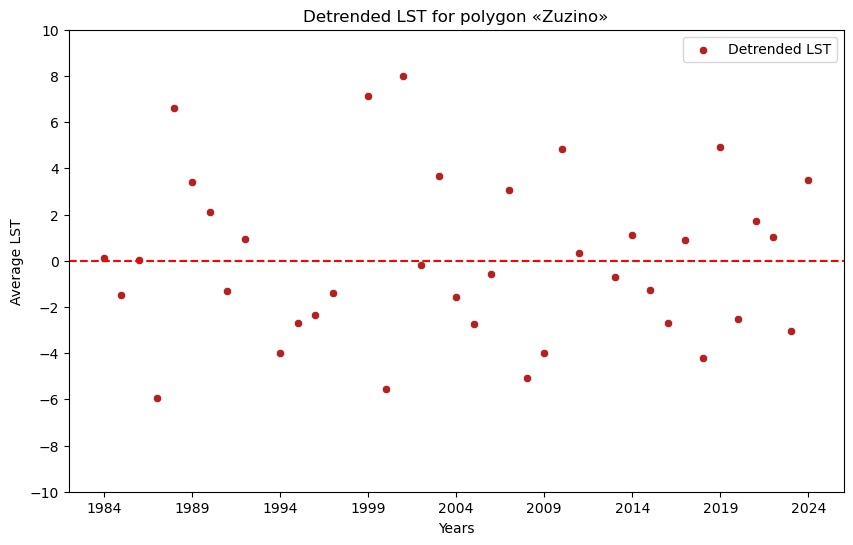

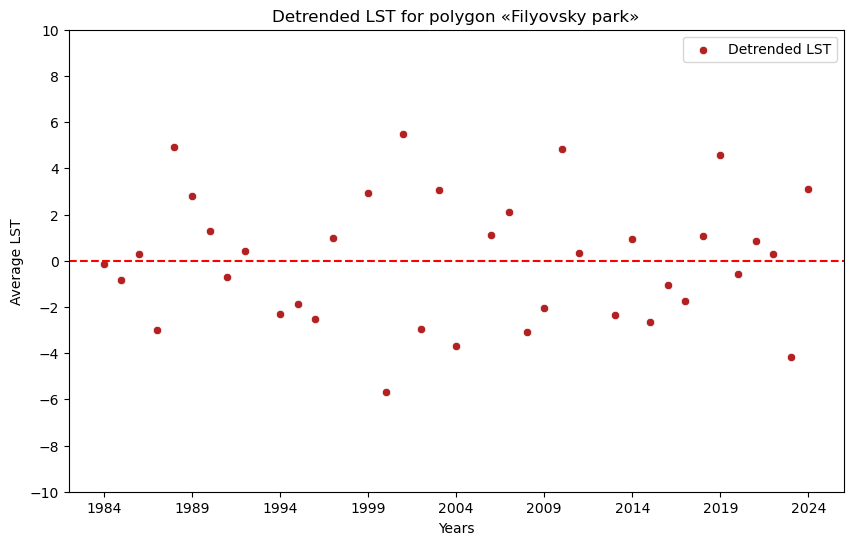

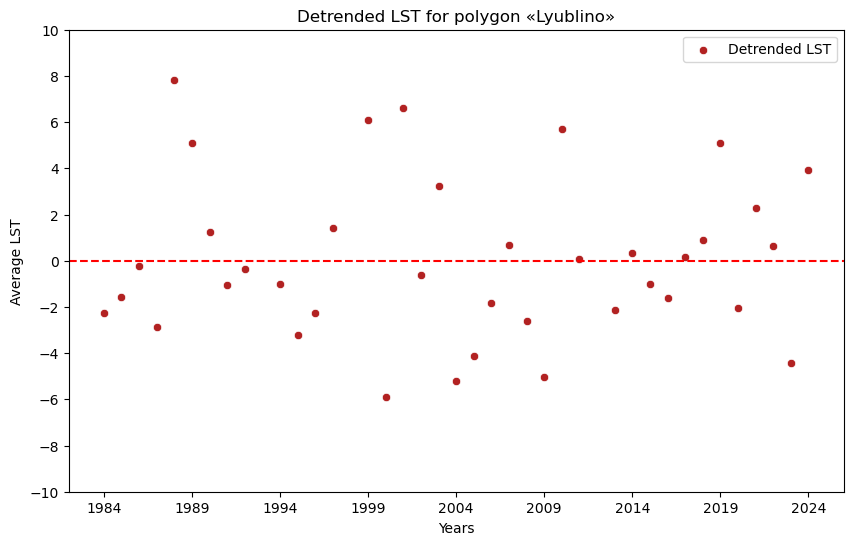

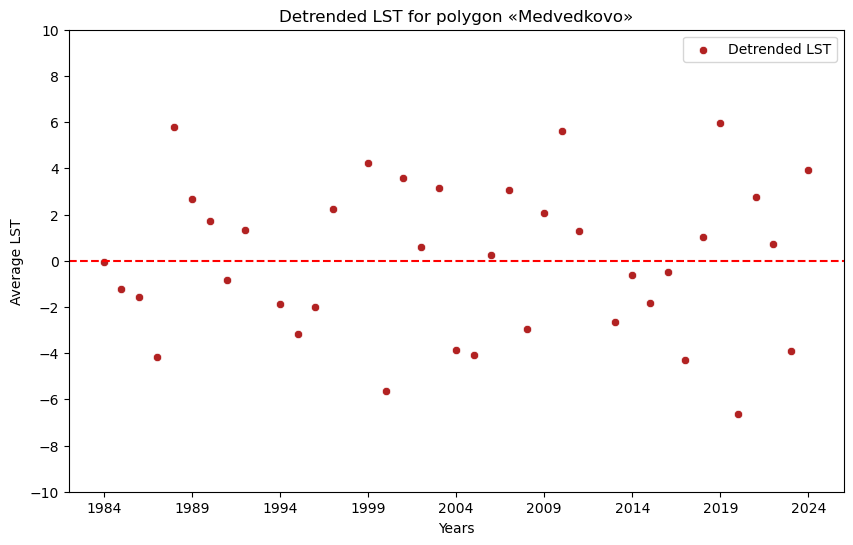

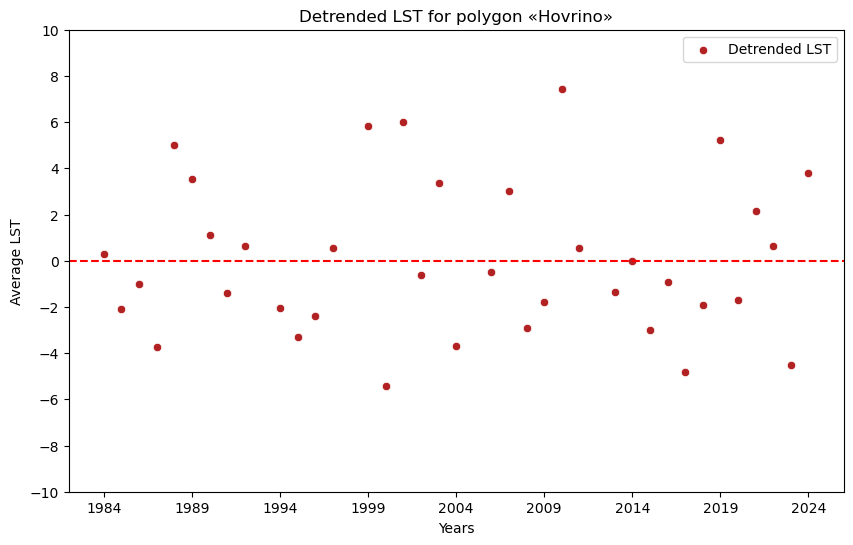

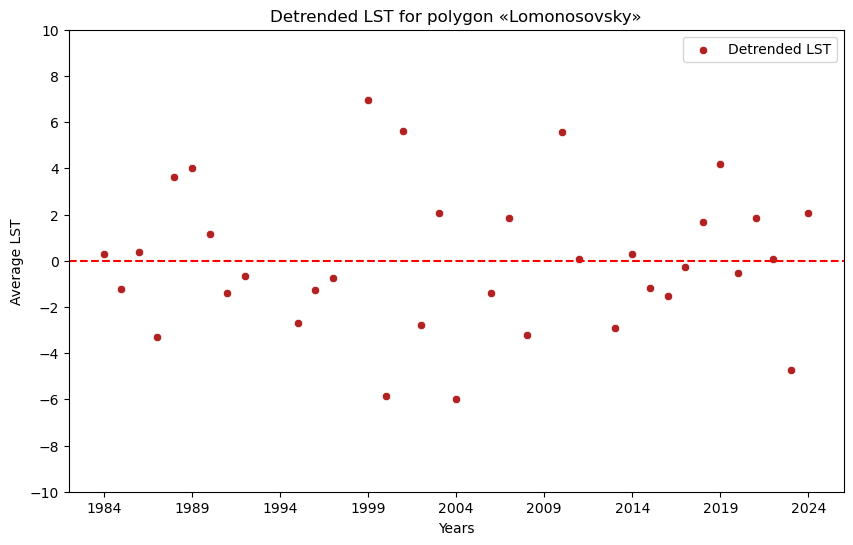

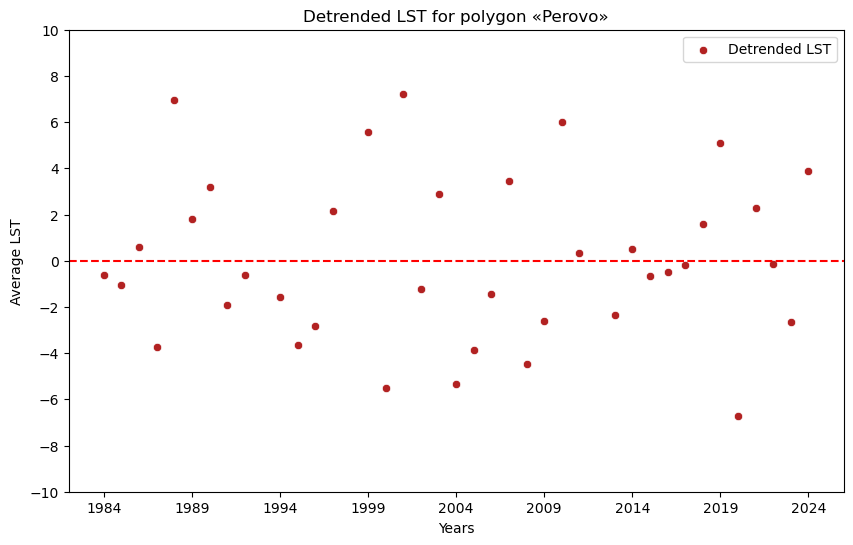

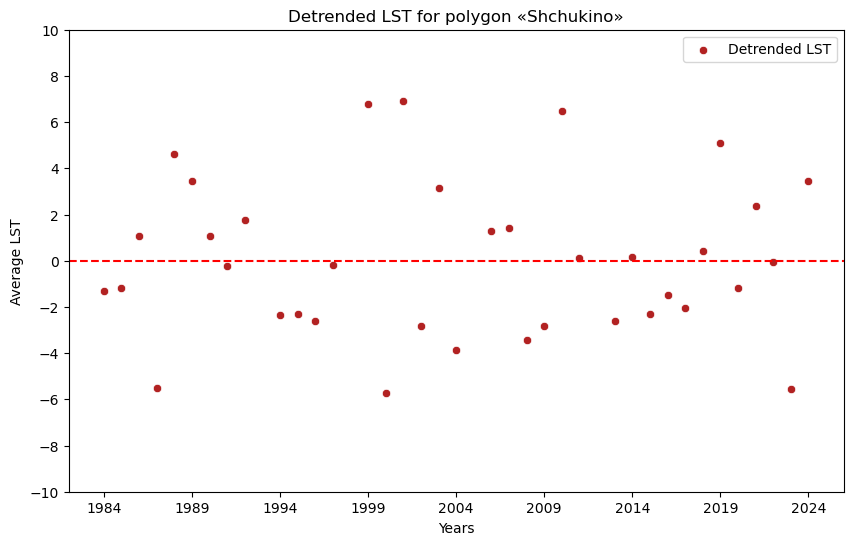

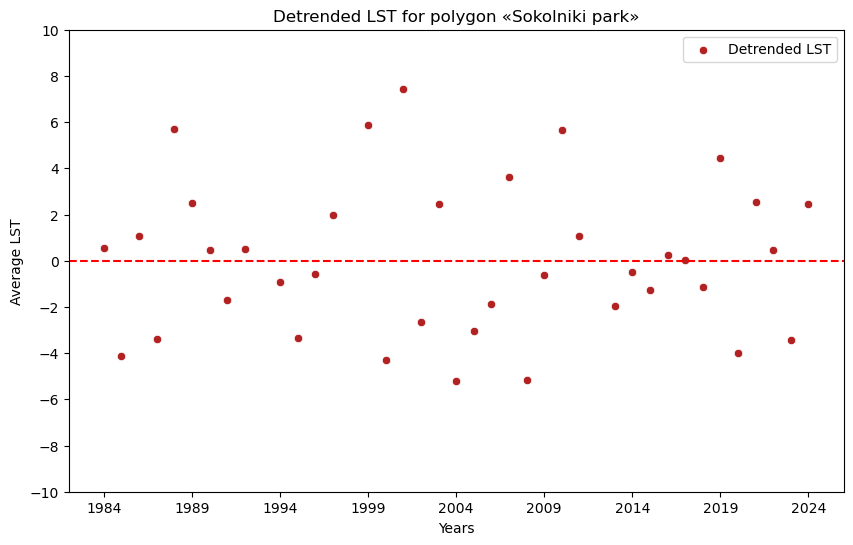

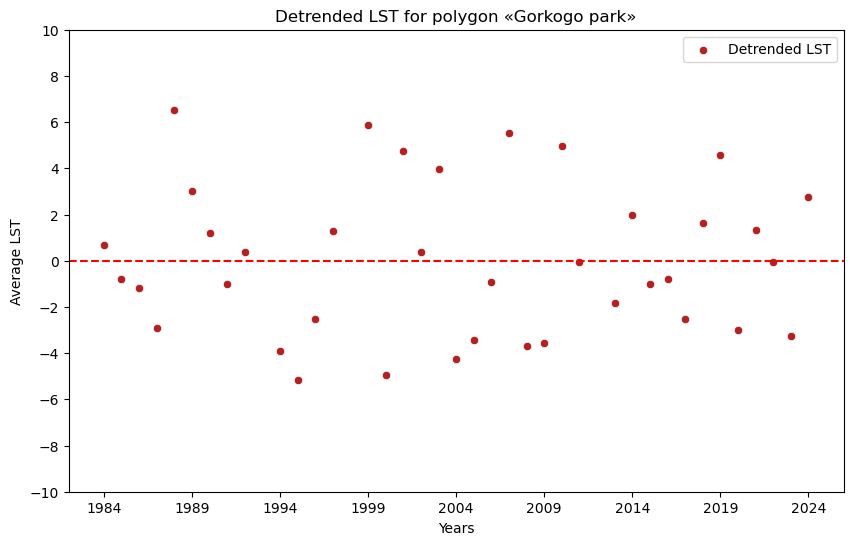

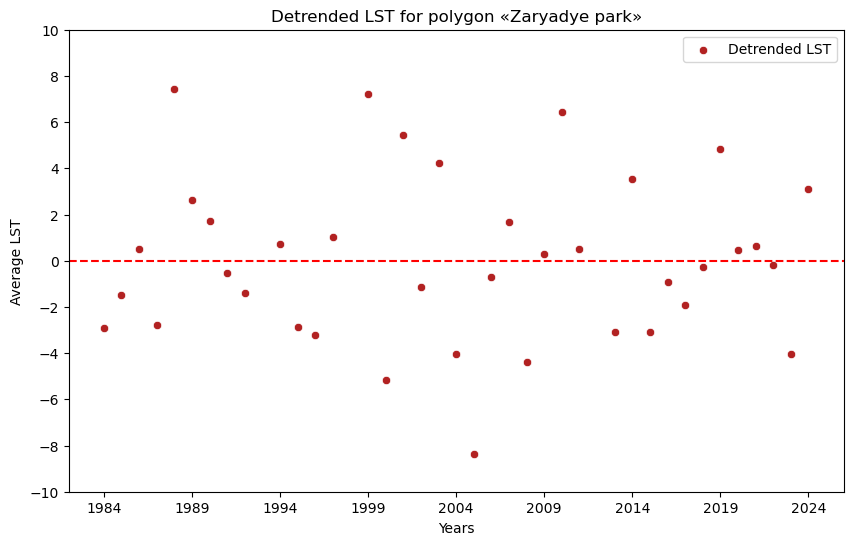

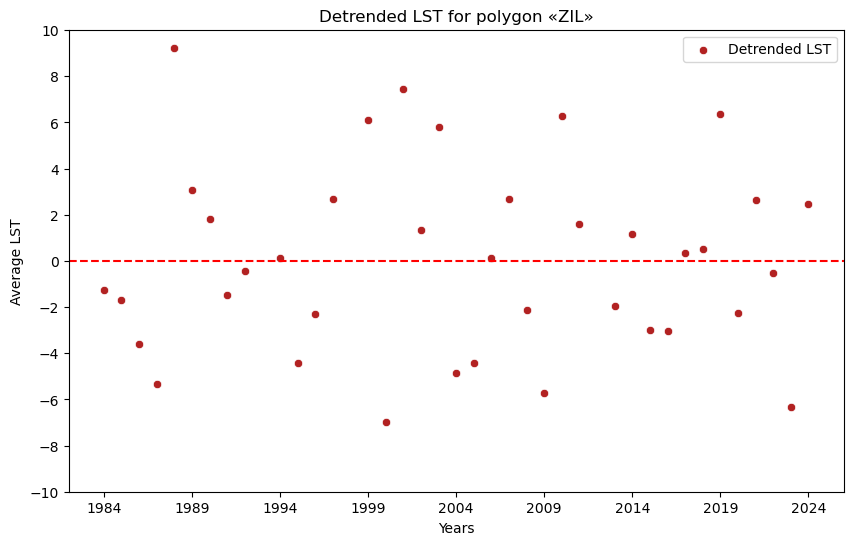

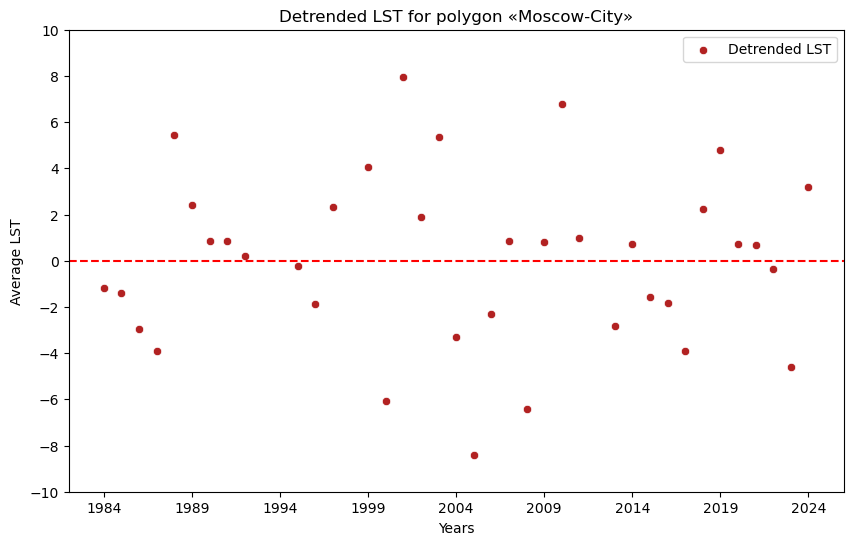

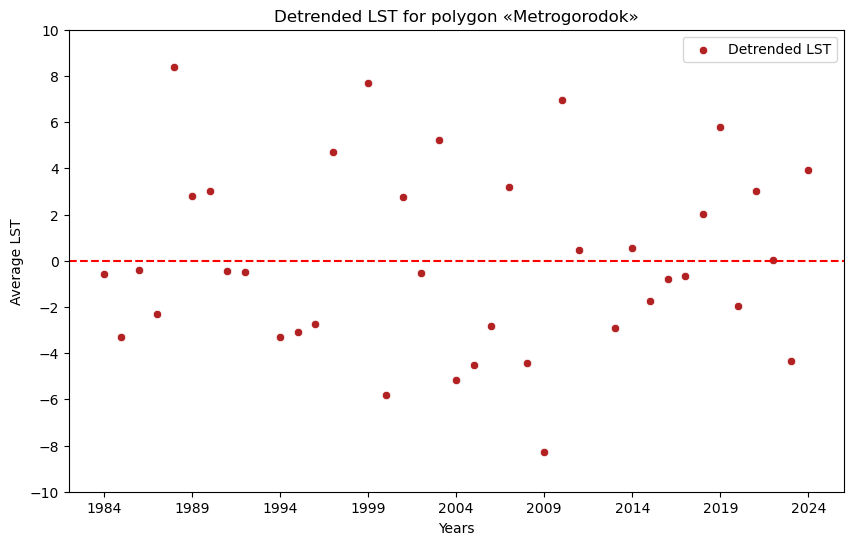

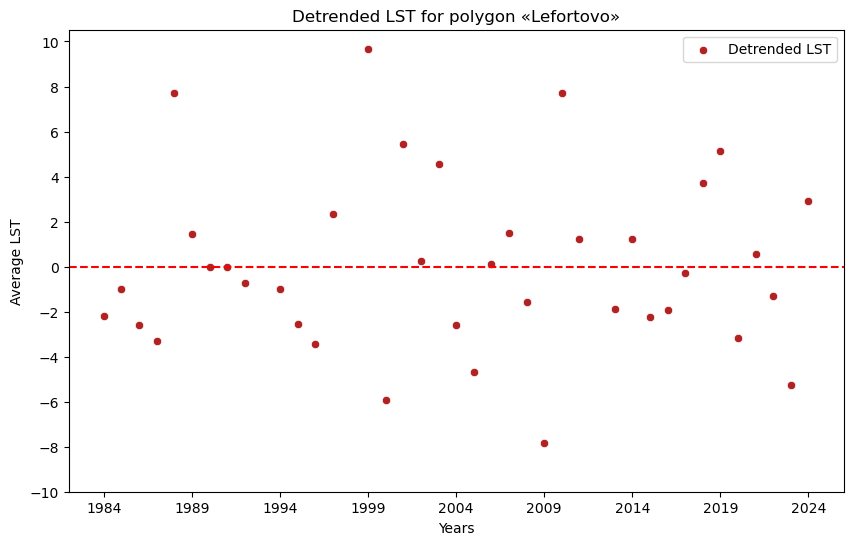

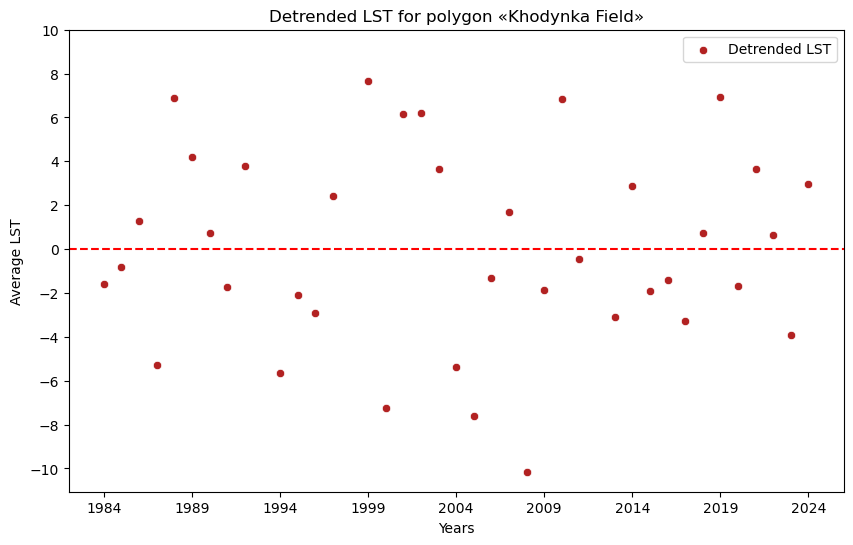

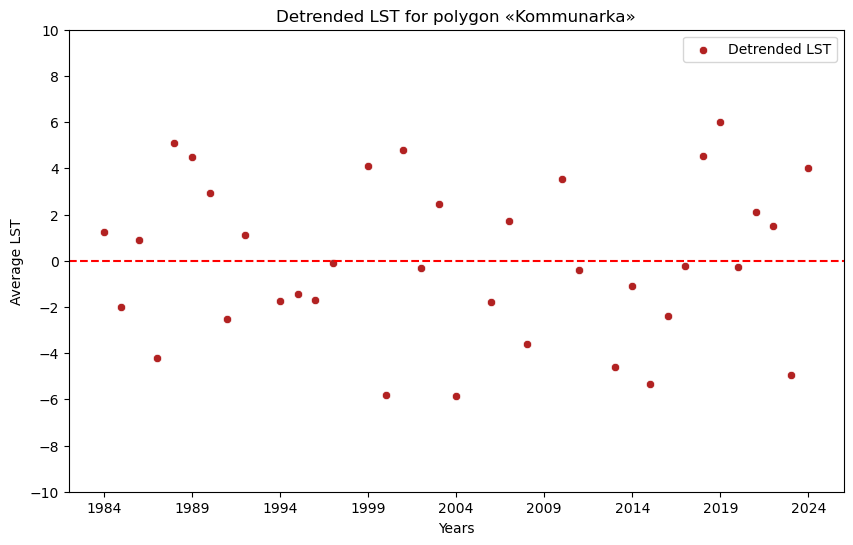

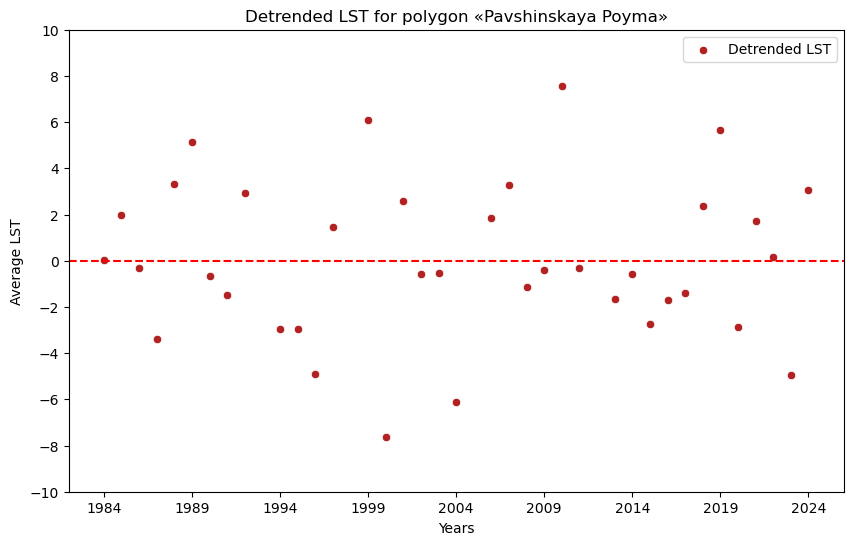

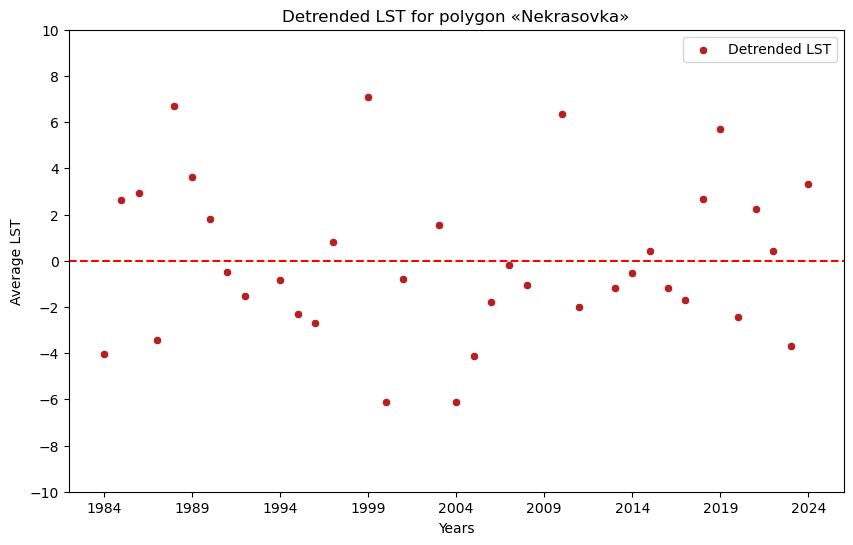

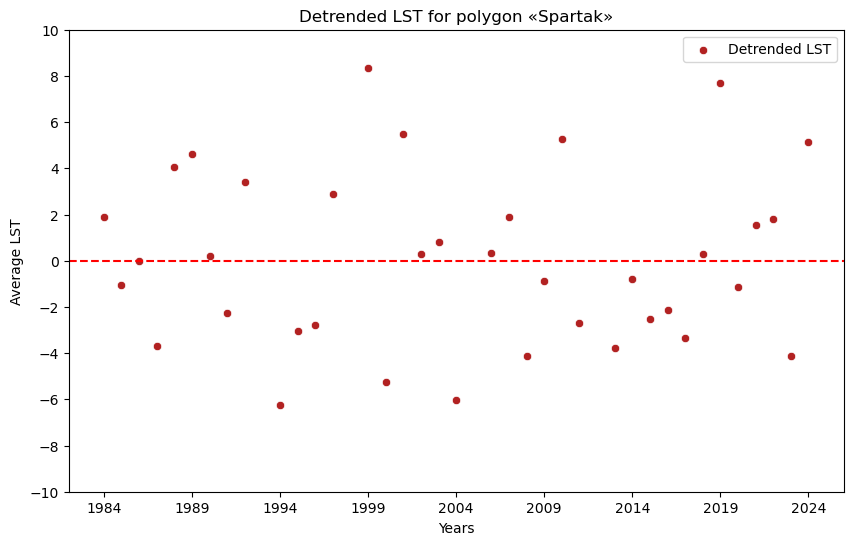

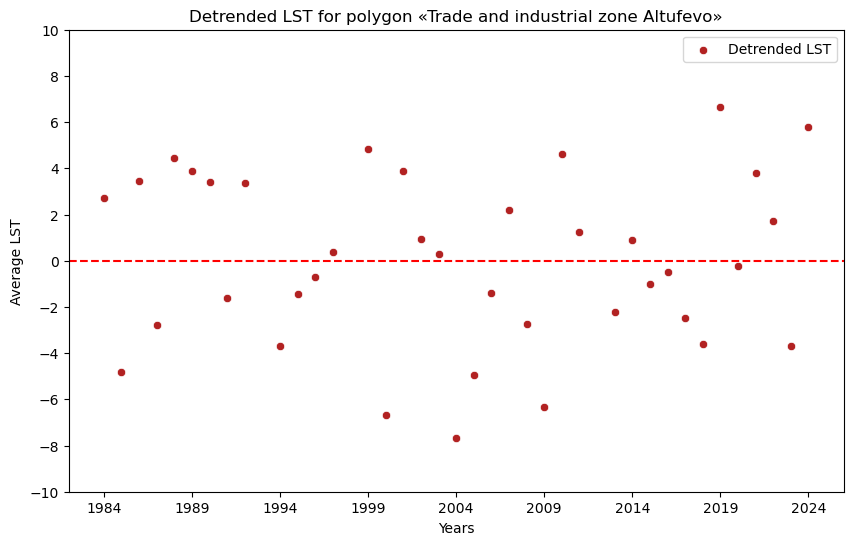

In [ ]:
# Cycle for each polygon
for ID in polygons_id:

    ts_poly_df_clean = df_clean.loc[ID]

    # Get polygon data (year + LST)
    x = ts_poly_df_clean['year']
    years_ticks = np.arange(x.min(), x.max()+1, 5)
    y = ts_poly_df_clean['mean_LST']

    lcz_name = ts_poly_df_clean['en_name'].iloc[0]

    # Detrend time series (delete linear trend)
    y_detrended = signal.detrend(y, type='linear')

    # Visualize detrended data
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=x, y=y_detrended, color='firebrick', label='Detrended Data')

    plt.axhline(0, color='red', ls='--')

    plt.xlabel('Years')
    plt.ylabel('Average LST')
    title = plt.title(f'Detrended LST for polygon «{lcz_name}»')
    plt.legend(['Detrended LST'])
    plt.xticks(years_ticks)
    plt.yticks(np.arange(-10,11, 2))

    # Save graph
    # plt.savefig(f'D:\Kursach_2\comps\plots\detrended\{title}.png', bbox_inches='tight')
    plt.show()


# View trend by class

In [ ]:
df_clean = df.dropna(subset=['mean_LST'])

In [ ]:
classes = df_clean['lcz'].unique()

In [ ]:
classes

array([1, 2, 3, 4, 5, 6, 7, 8], dtype=int64)

In [ ]:
df_clean = df_clean.reset_index()
df_clean = df_clean.sort_values('lcz')
df_clean = df_clean.set_index('lcz')

In [ ]:
df_clean

,index,lcz_id,lcz_name,mean_BU,mean_LST,mean_NDBI,en_name,year,classname
lcz,,,,,,,,,
1,0,11,moscvich,-0.273184,28.987634,-0.094475,Moskvich Factory,1984,Industrial areas
1,145,14,neft_moscow,-0.174326,36.866835,-0.024517,Moscow Oil Refinery,2018,Industrial areas
1,146,14,neft_moscow,-0.164091,38.390080,0.009166,Moscow Oil Refinery,2019,Industrial areas
1,147,14,neft_moscow,-0.222231,32.338871,-0.073896,Moscow Oil Refinery,2020,Industrial areas
1,148,14,neft_moscow,-0.134864,36.655693,0.011754,Moscow Oil Refinery,2021,Industrial areas
...,...,...,...,...,...,...,...,...,...
8,1371,83,pavshinskaya_poyma,-0.711548,21.933764,-0.254613,Pavshinskaya Poyma,1987,New development areas
8,1372,83,pavshinskaya_poyma,-0.795980,28.848171,-0.280431,Pavshinskaya Poyma,1988,New development areas
8,1373,83,pavshinskaya_poyma,-0.581324,30.926988,-0.161283,Pavshinskaya Poyma,1989,New development areas


### Construct similar plots of time trends by polygon classes

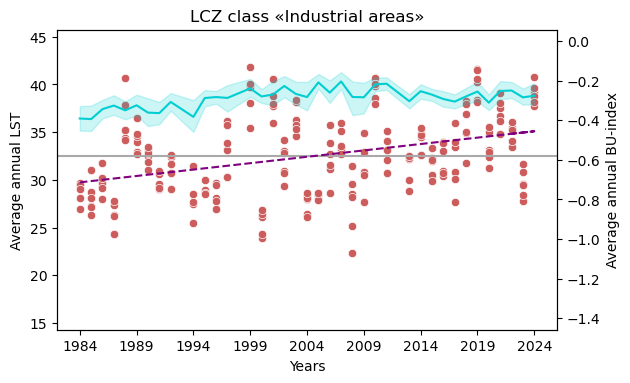

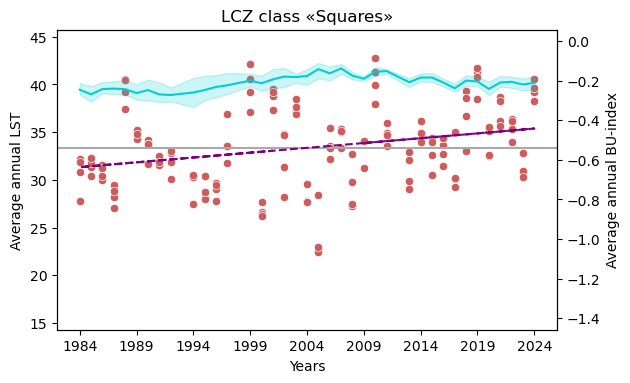

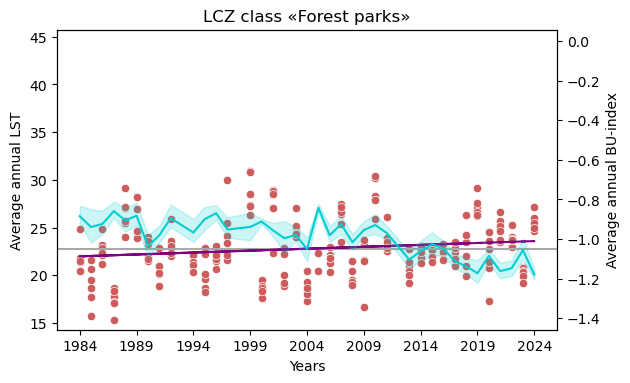

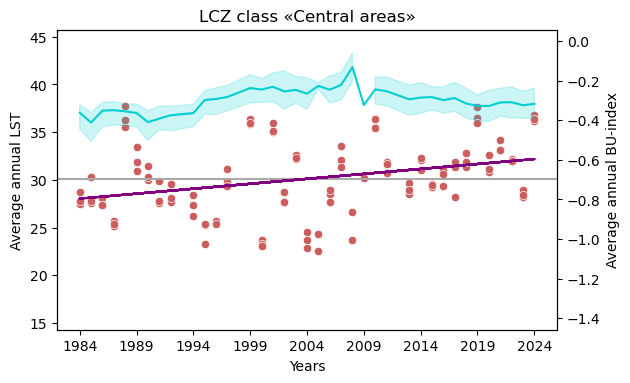

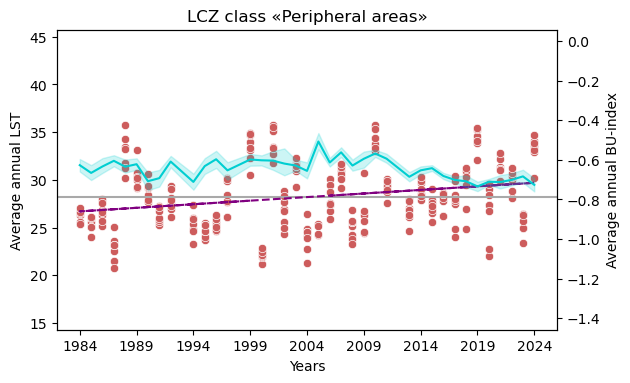

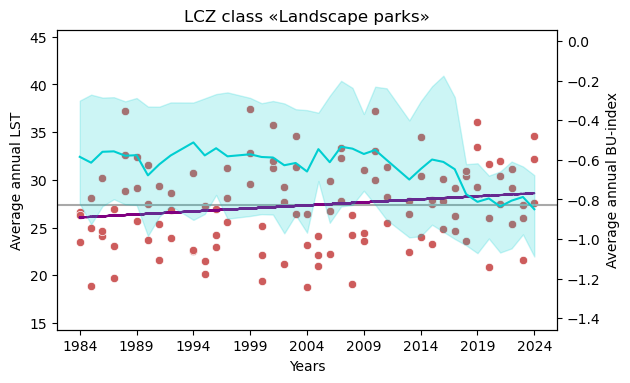

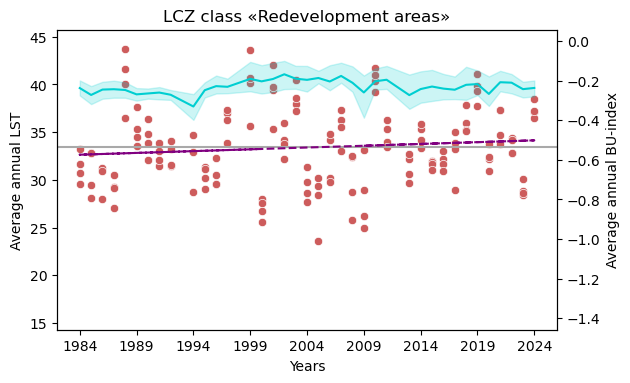

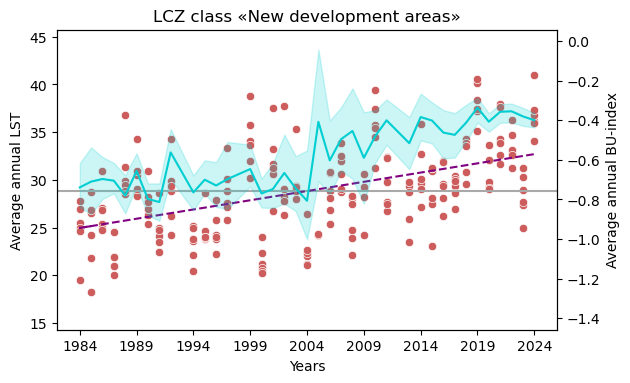

In [ ]:
for class_num in classes:

    ts_class_df_clean = df_clean.loc[class_num]

    x = ts_class_df_clean['year']
    years_ticks = np.arange(x.min(), x.max()+1, 5)

    y = ts_class_df_clean['mean_LST']
    ymin = df_clean['mean_LST'].min() - 1
    ymax = df_clean['mean_LST'].max() + 2

    y2 = ts_class_df_clean['mean_BU']
    y2min = df_clean['mean_BU'].min() - 0.2
    y2max = df_clean['mean_BU'].max() + 0.1

    fig = plt.figure(figsize=(5,3))
    ax1 = fig.add_axes([0,0,1,1])
    ax1.set_ylim(ymin, ymax)
    sns.scatterplot(x=x, y=y, ax=ax1, color='indianred')
    ax1.axhline(y.mean(), color='darkgrey')
    #plt.axhline(ts_poly_df_clean['mean_LST'].median(), color='purple')

    # Plot linear trend
    coeffs = np.polyfit(x, y, 1)
    polynomial = np.poly1d(coeffs)
    ax1.plot(x, polynomial(x), color='purple', ls='--')
    ax1.set_xlabel('Years')
    ax1.set_ylabel('Average annual LST')
    ax1.set_xticks(years_ticks)

    ax2 = ax1.twinx()
    ax2.set_ylim(y2min,y2max)
    ax2.set_ylabel('Average annual BU-index')
    sns.lineplot(x=x, y=y2, ax=ax2, color='darkturquoise')

    title = plt.title("LCZ class «"+ts_class_df_clean['classname'].iloc[0]+'»')
    plt.savefig(rf"D:\Kursach_2\newpics\{title}.png", bbox_inches='tight')

    plt.show()

### Statistical significance check-up

In [ ]:
df_clean

,index,lcz_id,lcz_name,mean_BU,mean_LST,mean_NDBI,en_name,year,classname
lcz,,,,,,,,,
1,0,11,moscvich,-0.273184,28.987634,-0.094475,Moskvich Factory,1984,Industrial areas
1,145,14,neft_moscow,-0.174326,36.866835,-0.024517,Moscow Oil Refinery,2018,Industrial areas
1,146,14,neft_moscow,-0.164091,38.390080,0.009166,Moscow Oil Refinery,2019,Industrial areas
1,147,14,neft_moscow,-0.222231,32.338871,-0.073896,Moscow Oil Refinery,2020,Industrial areas
1,148,14,neft_moscow,-0.134864,36.655693,0.011754,Moscow Oil Refinery,2021,Industrial areas
...,...,...,...,...,...,...,...,...,...
8,1371,83,pavshinskaya_poyma,-0.711548,21.933764,-0.254613,Pavshinskaya Poyma,1987,New development areas
8,1372,83,pavshinskaya_poyma,-0.795980,28.848171,-0.280431,Pavshinskaya Poyma,1988,New development areas
8,1373,83,pavshinskaya_poyma,-0.581324,30.926988,-0.161283,Pavshinskaya Poyma,1989,New development areas


In [ ]:
results_class = []

for class_num in classes:
    # Filter by class
    ts_class_df_clean = df_clean.loc[class_num]

    x = ts_class_df_clean['year'].values
    y = ts_class_df_clean['mean_LST'].values

    # Linear regression
    slope, intercept, r_value, p_value, std_err = st.linregress(x, y)

    # Save a result
    results_class.append({
        'lcz_class': class_num,
        'classname': ts_class_df_clean['classname'].iloc[0],
        'n_points': len(ts_class_df_clean),
        'slope': slope,
        'intercept': intercept,
        'r_value': r_value,
        'p_value': p_value,
        'std_err': std_err
    })

# To DataFrame
results_class_df = pd.DataFrame(results_class)

In [ ]:
results_class_df.sort_values('lcz_class')

# Temperature trend statistics by class

,lcz_class,classname,n_points,slope,intercept,r_value,p_value,std_err
0,1,Industrial areas,224,0.133947,-236.019176,0.386917,2.053487e-09,0.021425
1,2,Squares,148,0.101118,-169.290489,0.297494,2.406831e-04,0.026857
2,3,Forest parks,222,0.040040,-57.463339,0.157751,1.867735e-02,0.016898
3,4,Central areas,110,0.103641,-177.594671,0.336920,3.193103e-04,0.027869
4,5,Peripheral areas,298,0.074936,-121.982970,0.264420,3.691335e-06,0.015886
5,6,Landscape parks,114,0.063456,-99.843392,0.176713,5.999730e-02,0.033397
6,7,Redevelopment areas,151,0.037593,-41.954161,0.113037,1.669980e-01,0.027071
7,8,New development areas,222,0.193433,-358.816650,0.505657,8.201009e-16,0.022251


In [ ]:
results_class_df[results_class_df['p_value']<0.05]

# Statistically significant classes at significance level 0.05

,lcz_class,classname,n_points,slope,intercept,r_value,p_value,std_err
0,1,Industrial areas,224,0.133947,-236.019176,0.386917,2.053487e-09,0.021425
1,2,Squares,148,0.101118,-169.290489,0.297494,2.406831e-04,0.026857
2,3,Forest parks,222,0.040040,-57.463339,0.157751,1.867735e-02,0.016898
3,4,Central areas,110,0.103641,-177.594671,0.336920,3.193103e-04,0.027869
4,5,Peripheral areas,298,0.074936,-121.982970,0.264420,3.691335e-06,0.015886
7,8,New development areas,222,0.193433,-358.816650,0.505657,8.201009e-16,0.022251


In [ ]:
results_class_df[results_class_df['p_value']>0.05]

# Statistically unsignificant classes at significance level 0.05

,lcz_class,classname,n_points,slope,intercept,r_value,p_value,std_err
5,6,Landscape parks,114,0.063456,-99.843392,0.176713,0.059997,0.033397
6,7,Redevelopment areas,151,0.037593,-41.954161,0.113037,0.166998,0.027071


Class detrending using scipy.detrend

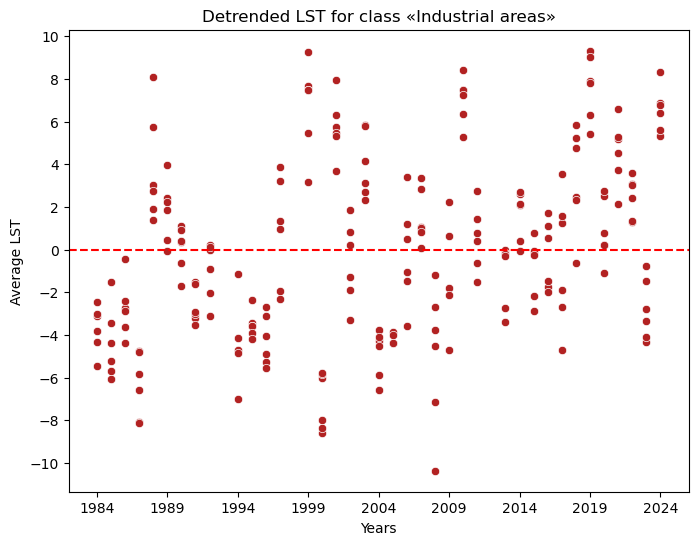

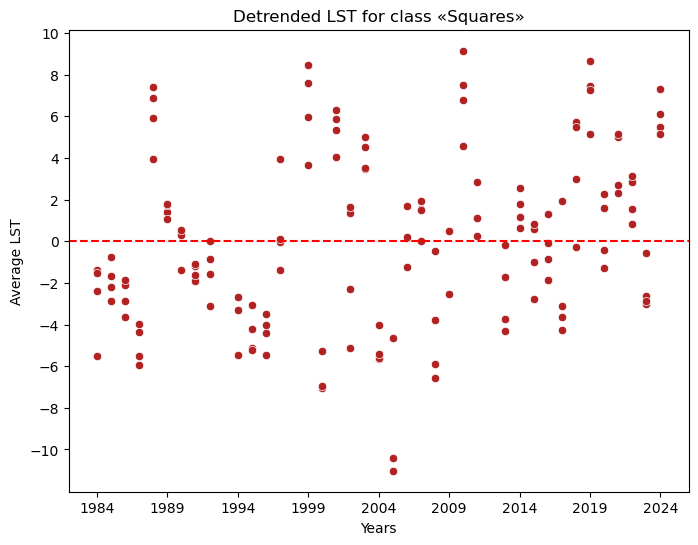

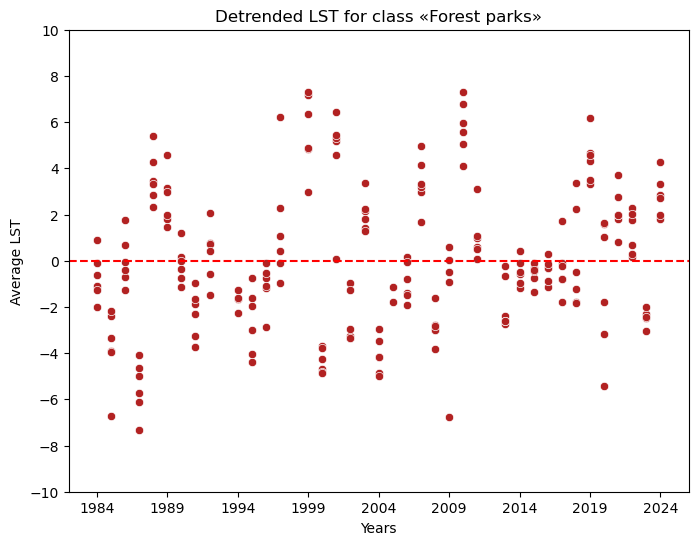

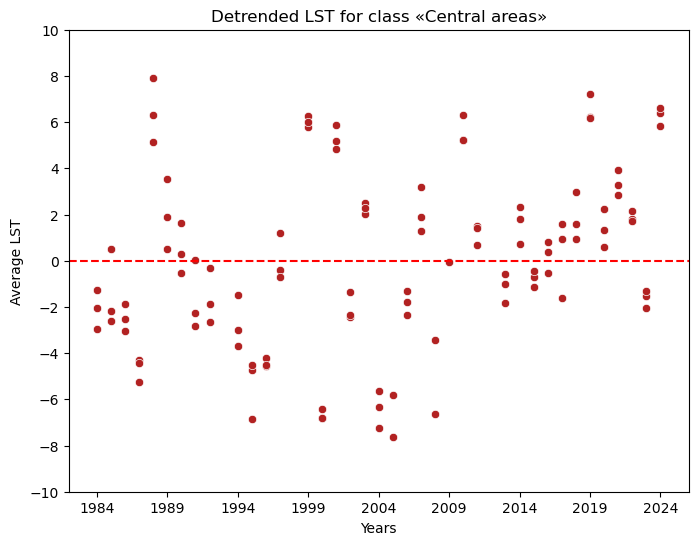

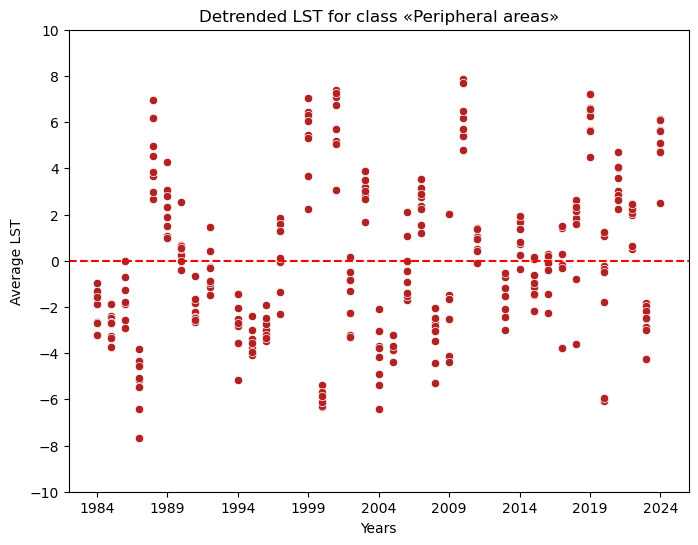

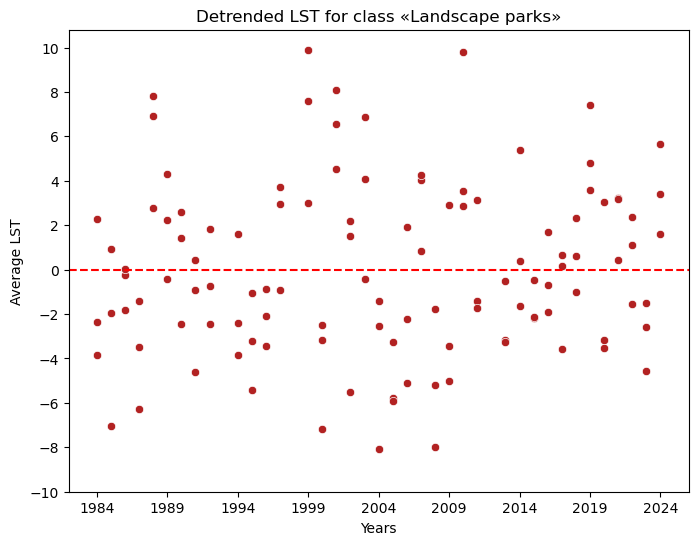

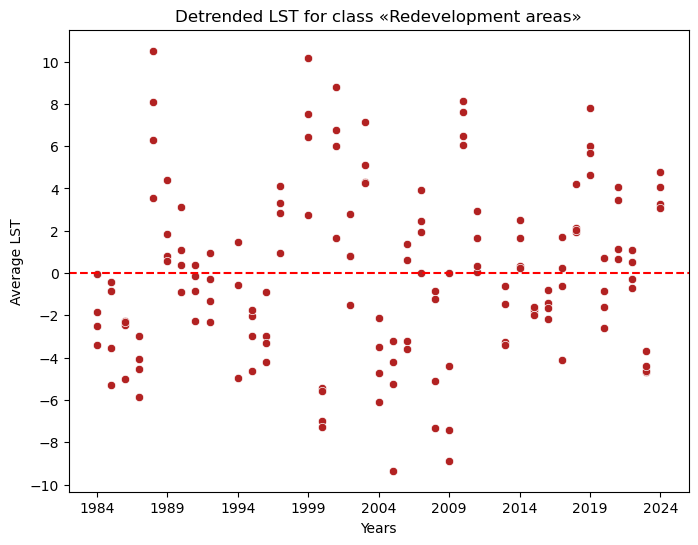

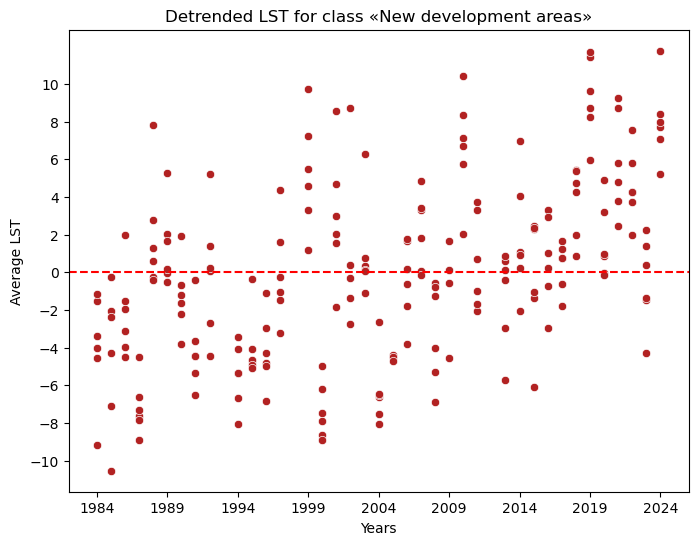

In [ ]:
# For each class
for class_num in classes:

    ts_class_df_clean = df_clean.loc[class_num]

    # Get class data (year + LST)
    x = ts_class_df_clean['year']
    years_ticks = np.arange(x.min(), x.max()+1, 5)
    y = ts_class_df_clean['mean_LST']

    lcz_class = ts_class_df_clean['classname'].iloc[0]

    # Detrend time series
    y_detrended = signal.detrend(y, type='linear')

    # Visualize detrended data
    fig, ax = plt.subplots(1,1, figsize=(8,6))
    #fig = plt.figure(figsize=(5,3))
    sns.scatterplot(x=x, y=y_detrended, color='firebrick', label='Detrended Data')

    plt.axhline(0, color='red', ls='--')

    plt.xlabel('Years')
    plt.ylabel('Average LST')
    title = plt.title(f'Detrended LST for class «{lcz_class}»')
    plt.xticks(years_ticks)
    plt.yticks(np.arange(-10,11, 2))
    ax.get_legend().remove()

    # Save graph
    # plt.savefig(f'D:\Kursach_2\comps\plots\detrended\{title}.png', bbox_inches='tight')
    plt.show()


# General check-up by class

In [ ]:
results_df[results_df['class'] == 1]

,class,lcz_id,lcz_name,n_points,slope,intercept,r_value,p_value,std_err
0,1,11,Moskvich Factory,38,0.130765,-228.365502,0.375792,0.020067,0.053744
1,1,12,Strogino industrial zone,37,0.162024,-291.936446,0.451539,0.005028,0.054117
2,1,13,Ochakovo-Matveevskoye industrial zone,37,0.118237,-205.631368,0.370808,0.023862,0.050055
3,1,14,Moscow Oil Refinery,37,0.122761,-214.558833,0.390669,0.016818,0.048894
4,1,15,Chertanovo industrial zone,37,0.115194,-198.080149,0.358904,0.029150,0.050638
5,1,16,Otradnoye industrial zone,38,0.152717,-273.592570,0.411191,0.010328,0.056425


In [ ]:
results_df[results_df['class'] == 2]

,class,lcz_id,lcz_name,n_points,slope,intercept,r_value,p_value,std_err
6,2,21,Red Square,37,0.080689,-129.584444,0.247991,0.138894,0.053280
7,2,22,Tryokh Vokzalov Square,37,0.137777,-242.051247,0.413057,0.011057,0.051347
8,2,23,Savyolovsky railway station,37,0.085237,-137.018483,0.257951,0.123215,0.053964
9,2,24,Kievsky railway station,37,0.100271,-167.510994,0.288416,0.083424,0.056268


In [ ]:
results_df[results_df['class'] == 3]

,class,lcz_id,lcz_name,n_points,slope,intercept,r_value,p_value,std_err
10,3,31,Losiny Ostrov,38,0.032433,-43.166169,0.137782,0.409418,0.038858
11,3,32,Bitsevsky park,35,0.048910,-76.148225,0.214964,0.214933,0.038682
12,3,33,Kuntsevsky park,37,0.067380,-112.641972,0.292617,0.078828,0.037218
13,3,34,Kuzminki park,38,0.021938,-20.775689,0.083301,0.619037,0.043740
14,3,35,Serebryany Bor,37,0.027254,-30.077454,0.106362,0.530953,0.043067
15,3,36,Timiryazevsky park,37,0.043503,-64.366062,0.182548,0.279517,0.039605


In [ ]:
results_df[results_df['class'] == 4]

,class,lcz_id,lcz_name,n_points,slope,intercept,r_value,p_value,std_err
16,4,41,Prechistenka,37,0.096228,-162.979797,0.317494,0.055514,0.048580
17,4,42,Sukharevskaya,36,0.090310,-150.456509,0.287365,0.089245,0.051624
18,4,43,Taganskaya,37,0.124449,-219.465923,0.411370,0.011423,0.046609


In [ ]:
results_df[results_df['class'] == 5]

,class,lcz_id,lcz_name,n_points,slope,intercept,r_value,p_value,std_err
19,5,51,Zuzino,38,0.075756,-123.792897,0.253782,0.124183,0.048123
20,5,52,Filyovsky park,37,0.119509,-211.298563,0.471593,0.003214,0.037773
21,5,53,Lyublino,38,0.077787,-126.706461,0.264365,0.108737,0.047295
22,5,54,Medvedkovo,38,0.060555,-92.967750,0.219560,0.185346,0.044845
23,5,55,Hovrino,37,0.083722,-140.043156,0.299292,0.071933,0.045116
24,5,56,Lomonosovsky,35,0.042830,-58.614915,0.171288,0.325190,0.042885
25,5,57,Perovo,38,0.045228,-62.581134,0.154391,0.354703,0.048239
26,5,58,Shchukino,37,0.094206,-160.137307,0.326271,0.048745,0.046134


In [ ]:
results_df[results_df['class'] == 6]

,class,lcz_id,lcz_name,n_points,slope,intercept,r_value,p_value,std_err
27,6,61,Sokolniki park,38,0.051869,-79.968758,0.191476,0.249485,0.044313
28,6,62,Gorkogo park,38,0.092662,-158.190727,0.327939,0.044433,0.044489
29,6,63,Zaryadye park,38,0.045837,-61.370692,0.155045,0.352645,0.048677


In [ ]:
results_df[results_df['class'] == 7]

,class,lcz_id,lcz_name,n_points,slope,intercept,r_value,p_value,std_err
30,7,71,ZIL,38,0.005899,22.794451,0.017772,0.915660,0.055312
31,7,72,Moscow-City,37,0.060716,-89.676013,0.198041,0.240007,0.050796
32,7,73,Metrogorodok,38,0.077804,-123.037941,0.232669,0.159803,0.054203
33,7,74,Lefortovo,38,0.008949,16.056685,0.028412,0.865538,0.052475


In [ ]:
results_df[results_df['class'] == 8]

,class,lcz_id,lcz_name,n_points,slope,intercept,r_value,p_value,std_err
34,8,81,Khodynka Field,38,0.120236,-209.134265,0.312526,5.608874e-02,0.060908
35,8,82,Kommunarka,36,0.152229,-278.204923,0.489584,2.441112e-03,0.046497
36,8,83,Pavshinskaya Poyma,37,0.200457,-373.007838,0.588290,1.284860e-04,0.046575
37,8,84,Nekrasovka,36,0.222683,-418.071050,0.637175,2.930977e-05,0.046194
38,8,85,Spartak,37,0.158696,-289.729726,0.463757,3.840138e-03,0.051246
39,8,86,Trade and industrial zone Altufevo,38,0.303915,-580.134609,0.705110,7.709641e-07,0.050939


## Autocorrelation test

In [ ]:
df_clean = df_clean.reset_index()

In [ ]:
from statsmodels.stats.stattools import durbin_watson

# Create dictionary for quick classes data access
grouped = df_clean.groupby('lcz')

# Function for Durbin-Watson statistics calculation
def compute_dw_for_class(class_id):
    ts = grouped.get_group(class_id)
    x = ts['year'].values
    y = ts['mean_LST'].values

    # Get slope, intercept, residuals and calculate Durbin-Watson for it
    slope = results_class_df.loc[results_class_df['lcz_class'] == class_id, 'slope'].iloc[0]
    intercept = results_class_df.loc[results_class_df['lcz_class'] == class_id, 'intercept'].iloc[0]
    resid = y - (slope * x + intercept)
    return durbin_watson(resid)

# Applying for each class and append as a column
results_class_df['durbin_watson'] = (
    results_class_df['lcz_class']
    .apply(compute_dw_for_class)
)

# Look at the result
print(results_class_df[['lcz_class','slope','p_value','durbin_watson']])


   lcz_class     slope       p_value  durbin_watson
0          1  0.133947  2.053487e-09       2.271459
1          2  0.101118  2.406831e-04       2.106767
2          3  0.040040  1.867735e-02       2.203238
3          4  0.103641  3.193103e-04       2.178822
4          5  0.074936  3.691335e-06       2.334221
5          6  0.063456  5.999730e-02       1.551717
6          7  0.037593  1.669980e-01       1.901091
7          8  0.193433  8.201009e-16       1.710332


Durbin-Watson statistics are in [1,5;2,5] range

### Check for randomness and normality of residuals

In [ ]:
lczs = df_clean['lcz'].unique().tolist()

In [ ]:
lczs

[1, 2, 3, 4, 5, 6, 7, 8]

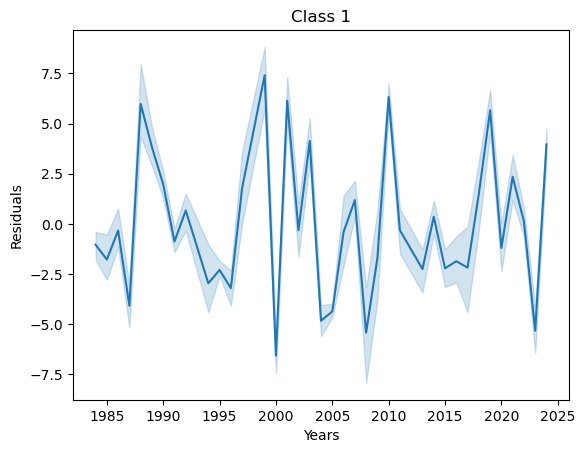

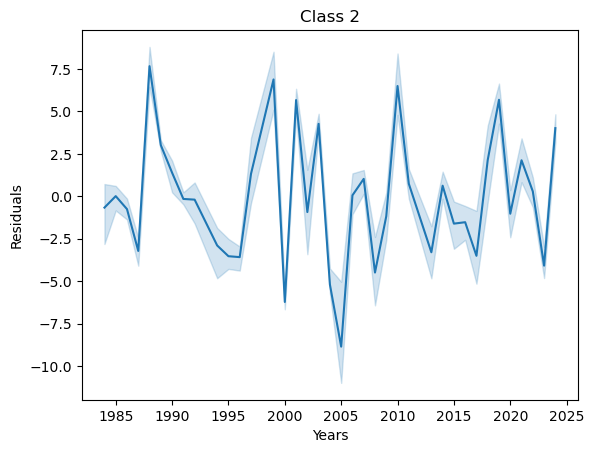

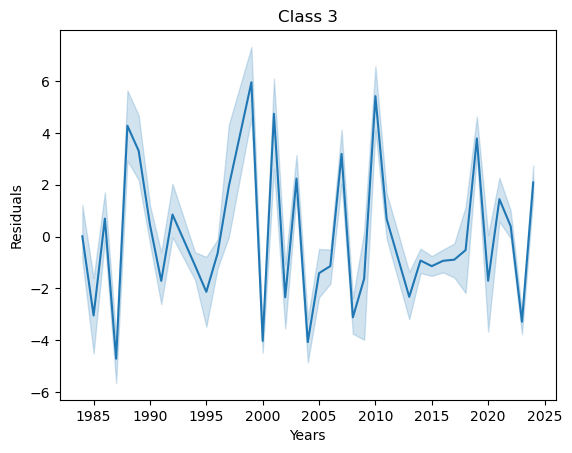

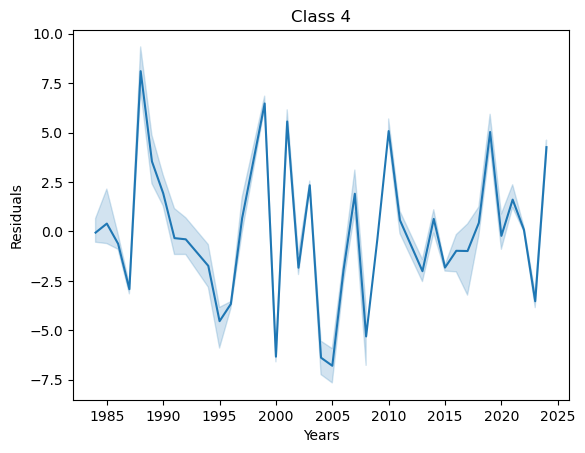

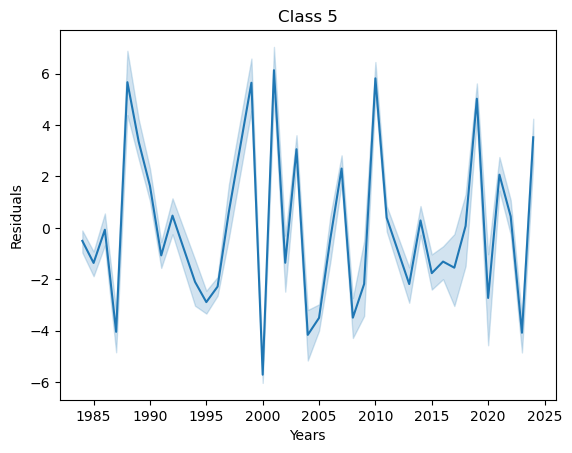

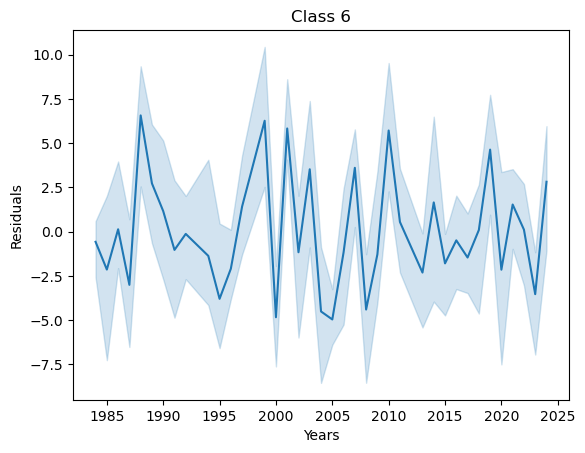

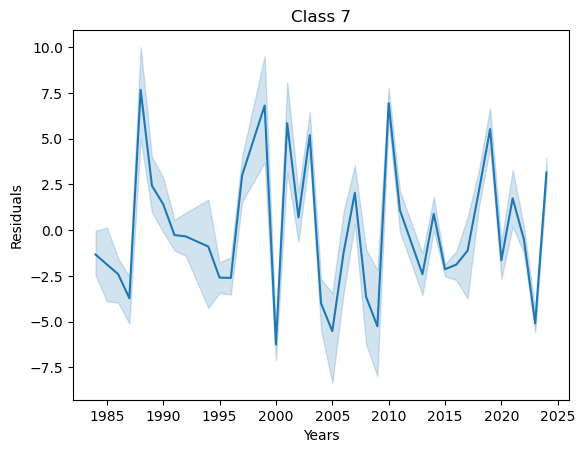

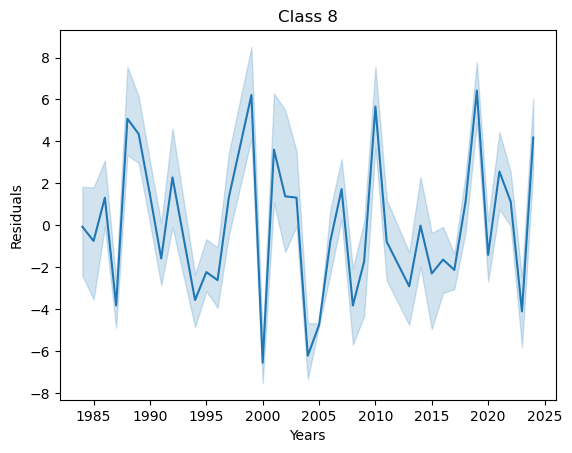

In [ ]:
# Residuals look random

resids = {}

for uniq in lczs:
    actual_data = df_clean.loc[df_clean['lcz'] == uniq].copy()
    trend_data = results_class_df.loc[results_class_df['lcz_class']==uniq].copy()
    actual_data['resids'] = actual_data['mean_LST'] - (actual_data['year'] * trend_data['slope'].iloc[0] + trend_data['intercept'].iloc[0])

    fig, ax = plt.subplots()
    sns.lineplot(data=actual_data, x='year', y='resids', ax=ax)
    ax.set_title('Class '+str(uniq))
    ax.set_xlabel('Years')
    ax.set_ylabel('Residuals')

    resids[uniq] = actual_data['resids'].tolist()

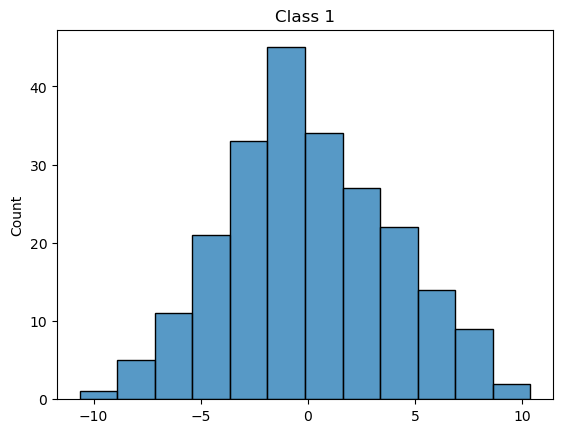

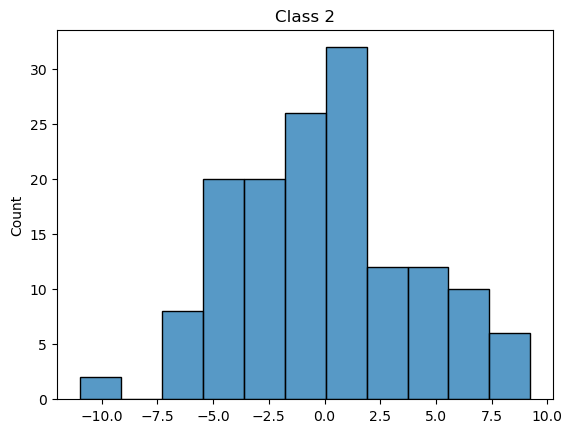

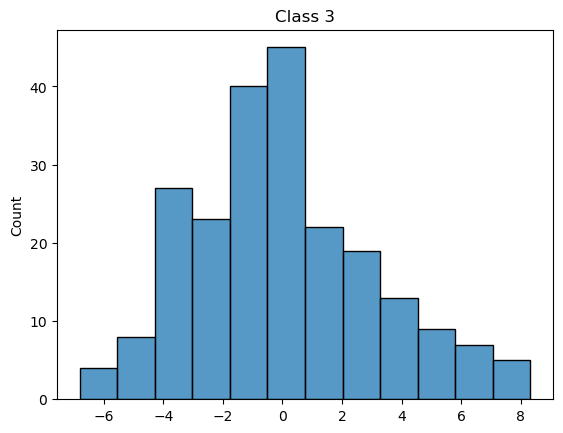

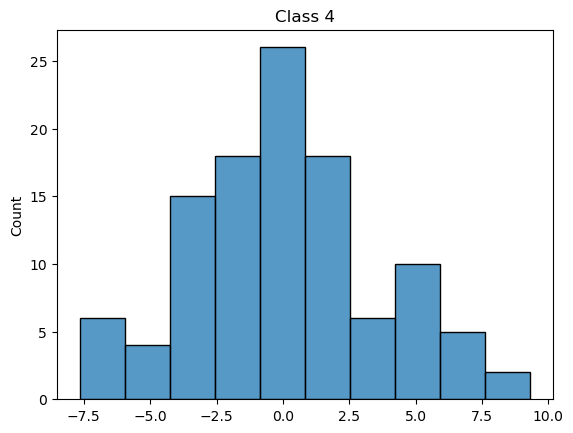

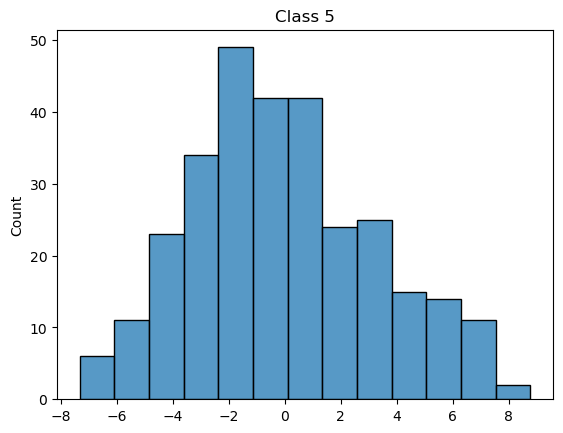

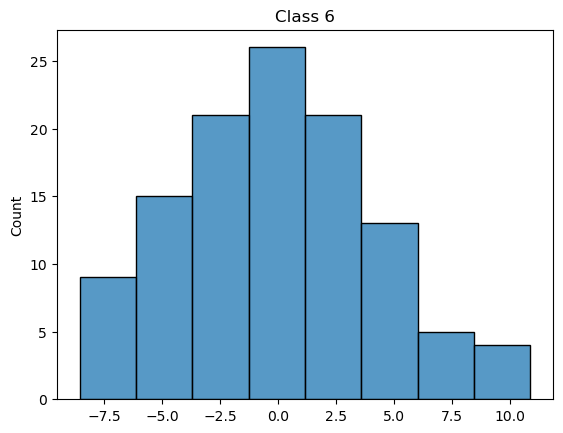

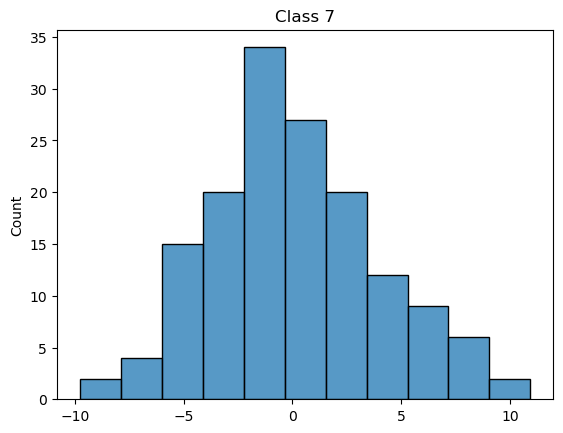

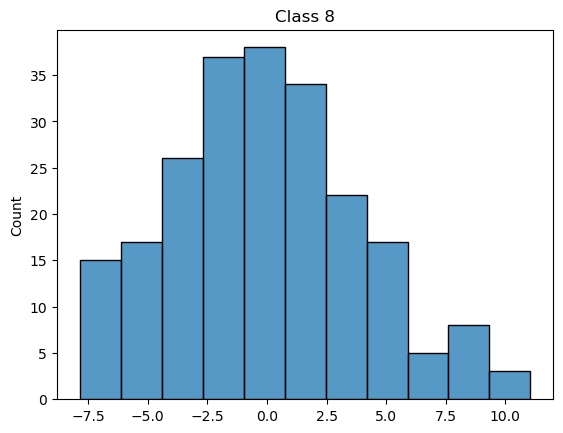

In [ ]:
# Residual histograms (not ideally normal, but normal-like)

for cls in resids.keys():
    resid = resids[cls]
    fig, ax = plt.subplots()
    sns.histplot(resid, ax=ax)
    plt.title(f'Class {cls}')

### Last look at the data

In [ ]:
df_clean

,lcz,index,lcz_id,lcz_name,mean_BU,mean_LST,mean_NDBI,en_name,year,classname
0,1,0,11,moscvich,-0.273184,28.987634,-0.094475,Moskvich Factory,1984,Industrial areas
1,1,145,14,neft_moscow,-0.174326,36.866835,-0.024517,Moscow Oil Refinery,2018,Industrial areas
2,1,146,14,neft_moscow,-0.164091,38.390080,0.009166,Moscow Oil Refinery,2019,Industrial areas
3,1,147,14,neft_moscow,-0.222231,32.338871,-0.073896,Moscow Oil Refinery,2020,Industrial areas
4,1,148,14,neft_moscow,-0.134864,36.655693,0.011754,Moscow Oil Refinery,2021,Industrial areas
...,...,...,...,...,...,...,...,...,...,...
1484,8,1371,83,pavshinskaya_poyma,-0.711548,21.933764,-0.254613,Pavshinskaya Poyma,1987,New development areas
1485,8,1372,83,pavshinskaya_poyma,-0.795980,28.848171,-0.280431,Pavshinskaya Poyma,1988,New development areas
1486,8,1373,83,pavshinskaya_poyma,-0.581324,30.926988,-0.161283,Pavshinskaya Poyma,1989,New development areas
1487,8,1361,82,kommunarka,-0.602723,33.494963,-0.176106,Kommunarka,2018,New development areas


In [ ]:
results_class_df

,lcz_class,classname,n_points,slope,intercept,r_value,p_value,std_err,durbin_watson
0,1,Industrial areas,224,0.133947,-236.019176,0.386917,2.053487e-09,0.021425,2.271459
1,2,Squares,148,0.101118,-169.290489,0.297494,2.406831e-04,0.026857,2.106767
2,3,Forest parks,222,0.040040,-57.463339,0.157751,1.867735e-02,0.016898,2.203238
3,4,Central areas,110,0.103641,-177.594671,0.336920,3.193103e-04,0.027869,2.178822
4,5,Peripheral areas,298,0.074936,-121.982970,0.264420,3.691335e-06,0.015886,2.334221
5,6,Landscape parks,114,0.063456,-99.843392,0.176713,5.999730e-02,0.033397,1.551717
6,7,Redevelopment areas,151,0.037593,-41.954161,0.113037,1.669980e-01,0.027071,1.901091
7,8,New development areas,222,0.193433,-358.816650,0.505657,8.201009e-16,0.022251,1.710332
